# BTTH Tuần 5

- Install and import libraries

In [1]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np

**Bài tập 1. Sử dụng Python cài đặt thuật toán K-Means**

Câu 1. Khởi tạo dữ liệu và cấu trúc cụm

In [3]:
# Khởi tạo dữ liệu vị trí khách hàng X dưới dạng numpy array
X = np.array([
    [1, 2],
    [2, 4],
    [3, 3],
    [4, 5],
    [5, 4],
    [6, 6],
    [7, 7],
    [8, 6],
    [9, 7],
    [10, 6],
    [11, 3],
    [12, 4],
    [13, 2],
    [14, 3],
    [15, 4]
])

# Khởi tạo số cụm k = 3
k = 3

# Khởi tạo tâm cụm ban đầu (chọn tùy ý, ví dụ chọn 3 điểm đầu tiên)
init_centers = {
    0: X[0],
    1: X[5],
    2: X[10]
}

# Xây dựng cấu trúc dữ liệu cho mỗi cụm (dictionary)
clusters = {}
for cluster_id in range(k):
    clusters[cluster_id] = {
        'center': init_centers[cluster_id],     # tọa độ tâm cụm (numpy array)
        'points': []                           # danh sách các điểm thuộc cụm
    }

print("Tập dữ liệu X:\n", X)
print("\nCấu trúc các cụm ban đầu:")
for cid, info in clusters.items():
    print(f"Cluster {cid}: center={info['center']}, points={info['points']}")

Tập dữ liệu X:
 [[ 1  2]
 [ 2  4]
 [ 3  3]
 [ 4  5]
 [ 5  4]
 [ 6  6]
 [ 7  7]
 [ 8  6]
 [ 9  7]
 [10  6]
 [11  3]
 [12  4]
 [13  2]
 [14  3]
 [15  4]]

Cấu trúc các cụm ban đầu:
Cluster 0: center=[1 2], points=[]
Cluster 1: center=[6 6], points=[]
Cluster 2: center=[11  3], points=[]


Câu 2. Định nghĩa hàm distance(p1, p2) để tính khoảng cách Euclid giữa 2 điểm dữ liệu

In [4]:
def distance(p1, p2):
    """
    Tính khoảng cách Euclid giữa hai điểm p1 và p2.
    p1, p2: numpy array hoặc list cùng chiều.
    Trả về: float - khoảng cách Euclid.
    """
    p1 = np.array(p1)
    p2 = np.array(p2)
    return np.sqrt(np.sum((p1 - p2) ** 2))

Câu 3. Định nghĩa hàm assign_clusters(X, clusters) để gán từng điểm dữ liệu đến cụm
gần nhất

In [5]:
def assign_clusters(X, clusters):
    # Reset danh sách points của tất cả các cụm
    for cluster_id in clusters:
        clusters[cluster_id]['points'] = []

    for idx, point in enumerate(X):
        print(f"Point {list(point)}:")
        dist = []
        # Tính khoảng cách từ điểm này đến từng tâm cụm
        for cluster_id, info in clusters.items():
            d = distance(point, info['center'])
            dist.append(d)
            print(f" Distance to Cluster {cluster_id} (center={list(info['center'])}): {d}")
        # Xác định chỉ số cụm gần nhất
        nearest_cluster = np.argmin(dist)
        print(f" -> Assigned to Cluster {nearest_cluster}")
        # Thêm điểm vào cụm gần nhất
        clusters[nearest_cluster]['points'].append(point)
    return clusters

# Gọi hàm để gán điểm vào cụm (in khoảng cách + cụm được chọn)
clusters = assign_clusters(X, clusters)

Point [np.int64(1), np.int64(2)]:
 Distance to Cluster 0 (center=[np.int64(1), np.int64(2)]): 0.0
 Distance to Cluster 1 (center=[np.int64(6), np.int64(6)]): 6.4031242374328485
 Distance to Cluster 2 (center=[np.int64(11), np.int64(3)]): 10.04987562112089
 -> Assigned to Cluster 0
Point [np.int64(2), np.int64(4)]:
 Distance to Cluster 0 (center=[np.int64(1), np.int64(2)]): 2.23606797749979
 Distance to Cluster 1 (center=[np.int64(6), np.int64(6)]): 4.47213595499958
 Distance to Cluster 2 (center=[np.int64(11), np.int64(3)]): 9.055385138137417
 -> Assigned to Cluster 0
Point [np.int64(3), np.int64(3)]:
 Distance to Cluster 0 (center=[np.int64(1), np.int64(2)]): 2.23606797749979
 Distance to Cluster 1 (center=[np.int64(6), np.int64(6)]): 4.242640687119285
 Distance to Cluster 2 (center=[np.int64(11), np.int64(3)]): 8.0
 -> Assigned to Cluster 0
Point [np.int64(4), np.int64(5)]:
 Distance to Cluster 0 (center=[np.int64(1), np.int64(2)]): 4.242640687119285
 Distance to Cluster 1 (center=[n

Câu 4. Định nghĩa hàm update_clusters(clusters) để cập nhật lại tâm mới của từng cụm dựa trên giá trị trung bình của các điểm gán cho mỗi cụm.

In [6]:
def update_clusters(clusters):
    for cluster_id, info in clusters.items():
        print(f"Cluster {cluster_id}:")
        points = info['points']
        points_list = [np.asarray(p).tolist() for p in points]
        print(f" Points: {points_list}")

        if len(points) > 0:
            print(f" Old center: {np.asarray(info['center']).tolist()}")
            new_center = np.array(points).mean(axis=0)
            print(f" New center: {new_center.tolist()}")
            clusters[cluster_id]['center'] = new_center
        else:
            print(" No points assigned → center unchanged")

    return clusters

clusters = update_clusters(clusters)

Cluster 0:
 Points: [[1, 2], [2, 4], [3, 3]]
 Old center: [1, 2]
 New center: [2.0, 3.0]
Cluster 1:
 Points: [[4, 5], [5, 4], [6, 6], [7, 7], [8, 6], [9, 7]]
 Old center: [6, 6]
 New center: [6.5, 5.833333333333333]
Cluster 2:
 Points: [[10, 6], [11, 3], [12, 4], [13, 2], [14, 3], [15, 4]]
 Old center: [11, 3]
 New center: [12.5, 3.6666666666666665]


Câu 5. Định nghĩa hàm kmeans(X, init_centers, max_iters, tol) để lặp toàn bộ thuật toán K-means cho đến khi hội tụ

In [7]:
def kmeans(X, init_centers, max_iters, tol):
    k = len(init_centers)
    clusters = {}
    for cluster_id, center in init_centers.items():
        clusters[cluster_id] = {
            'center': np.array(center, dtype=float).copy(),
            'points': []
        }

    print("=== Initial Centers ===")
    for cluster_id in sorted(clusters.keys()):
        print(f"Cluster {cluster_id}: {clusters[cluster_id]['center'].tolist()}")

    for iteration in range(max_iters):
        print(f"\n=== Iteration {iteration + 1} ===")

        clusters = assign_clusters(X, clusters)

        prev_centers = {
            cid: clusters[cid]['center'].copy() for cid in clusters
        }

        clusters = update_clusters(clusters)

        converged = True
        for cluster_id in sorted(clusters.keys()):
            new_center = clusters[cluster_id]['center']
            prev_center = prev_centers[cluster_id]
            shift = np.linalg.norm(new_center - prev_center)
            print(f" Cluster {cluster_id} shift: {shift}")
            if shift >= tol:
                converged = False

        if converged:
            print(f"\nConverged after {iteration + 1} iteration(s).")
            break
    else:
        print(f"\nStopped: reached max_iters={max_iters} without convergence.")

    return clusters


max_iters = 100
tol = 1e-4
clusters = kmeans(X, init_centers, max_iters, tol)

=== Initial Centers ===
Cluster 0: [1.0, 2.0]
Cluster 1: [6.0, 6.0]
Cluster 2: [11.0, 3.0]

=== Iteration 1 ===
Point [np.int64(1), np.int64(2)]:
 Distance to Cluster 0 (center=[np.float64(1.0), np.float64(2.0)]): 0.0
 Distance to Cluster 1 (center=[np.float64(6.0), np.float64(6.0)]): 6.4031242374328485
 Distance to Cluster 2 (center=[np.float64(11.0), np.float64(3.0)]): 10.04987562112089
 -> Assigned to Cluster 0
Point [np.int64(2), np.int64(4)]:
 Distance to Cluster 0 (center=[np.float64(1.0), np.float64(2.0)]): 2.23606797749979
 Distance to Cluster 1 (center=[np.float64(6.0), np.float64(6.0)]): 4.47213595499958
 Distance to Cluster 2 (center=[np.float64(11.0), np.float64(3.0)]): 9.055385138137417
 -> Assigned to Cluster 0
Point [np.int64(3), np.int64(3)]:
 Distance to Cluster 0 (center=[np.float64(1.0), np.float64(2.0)]): 2.23606797749979
 Distance to Cluster 1 (center=[np.float64(6.0), np.float64(6.0)]): 4.242640687119285
 Distance to Cluster 2 (center=[np.float64(11.0), np.float64

**Bài tập 2. Cài đặt thuật toán K-Means bằng thư viện sklearn**

In [8]:
%pip install pandas matplotlib scikit-learn plotly "nbformat>=4.2.0" -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

**Câu 1.** Nhập dữ liệu, thống kê các thông tin cơ bản, xử lý dữ liệu bị thiếu

In [10]:
# Nhập dữ liệu Mall Customer Segmentation
csv_path = Path("Mall_Customers.csv")
df = pd.read_csv(csv_path)

print("=== 1. Xem trước dữ liệu ===")
display(df.head(10))

print("\n=== 2. Kích thước & kiểu dữ liệu ===")
print(f"Số khách hàng (dòng): {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(df.dtypes)

print("\n=== 3. Thống kê mô tả (Tuổi, Thu nhập, Điểm mua sắm) ===")
display(df.describe())

print("\n=== 4. Thống kê Giới tính (Gender) ===")
print(df["Gender"].value_counts())
print("\nTỷ lệ (%):")
print((df["Gender"].value_counts(normalize=True) * 100).round(2))

print("\n=== 5. Kiểm tra dữ liệu thiếu (missing) ===")
missing = df.isnull().sum()
missing_table = pd.DataFrame({
    "Số giá trị thiếu": missing,
    "Tỷ lệ %": (missing / len(df) * 100).round(2)
})
display(missing_table)
print(f"Tổng số ô thiếu: {int(missing.sum())}")

# Xử lý dữ liệu thiếu
n_before = len(df)
if missing.sum() == 0:
    print("\n→ Không có dữ liệu thiếu → giữ nguyên bảng df.")
else:
    df = df.dropna()
    print(f"\n→ Đã loại {n_before - len(df)} dòng có giá trị thiếu.")
    print(f"   Còn lại {len(df)} dòng.")

print("\n=== 6. Dữ liệu sau xử lý ===")
display(df.head())

=== 1. Xem trước dữ liệu ===


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



=== 2. Kích thước & kiểu dữ liệu ===
Số khách hàng (dòng): 200
Số cột: 5
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

=== 3. Thống kê mô tả (Tuổi, Thu nhập, Điểm mua sắm) ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



=== 4. Thống kê Giới tính (Gender) ===
Gender
Female    112
Male       88
Name: count, dtype: int64

Tỷ lệ (%):
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

=== 5. Kiểm tra dữ liệu thiếu (missing) ===


,Số giá trị thiếu,Tỷ lệ %
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0


Tổng số ô thiếu: 0

→ Không có dữ liệu thiếu → giữ nguyên bảng df.

=== 6. Dữ liệu sau xử lý ===


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Câu 2. Sử dụng biểu đồ histogram để biểu diễn phân phối của lần lượt các thuộc tính Tuổi, Thu nhập hằng năm và Số điểm mua sắm

In [11]:
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.


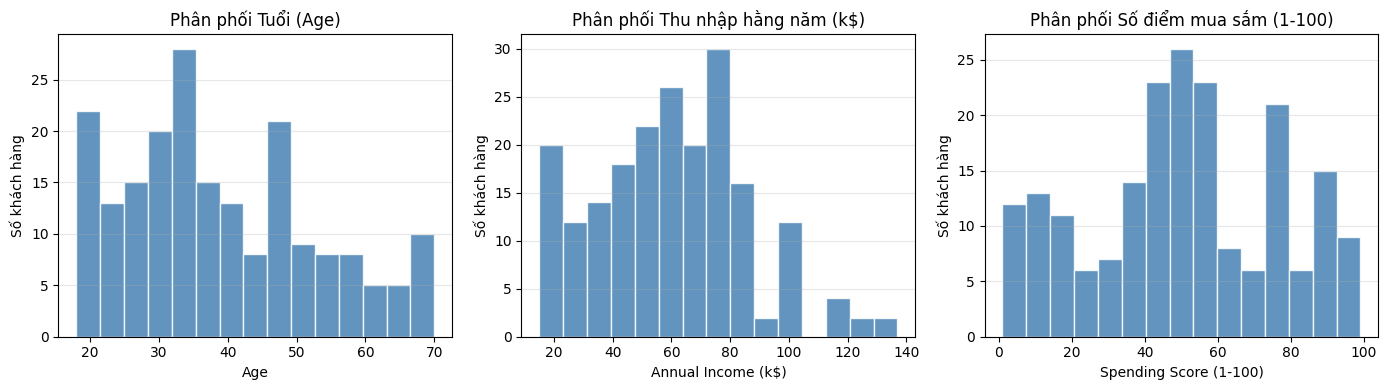

In [12]:
import matplotlib.pyplot as plt

cols = [
    ("Age", "Tuổi (Age)"),
    ("Annual Income (k$)", "Thu nhập hằng năm (k$)"),
    ("Spending Score (1-100)", "Số điểm mua sắm (1-100)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, title) in zip(axes, cols):
    ax.hist(df[col], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(f"Phân phối {title}")
    ax.set_xlabel(col)
    ax.set_ylabel("Số khách hàng")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Câu 3. Thống kê số mẫu dữ liệu theo thuộc tính Giới tính.

In [13]:
print("=== Số mẫu theo Giới tính ===")
gender_counts = df["Gender"].value_counts().sort_index()
display(gender_counts.to_frame("Số mẫu"))
print("\nTỷ lệ (%):")
display((gender_counts / len(df) * 100).round(2).to_frame("Tỷ lệ %"))
print(f"Tổng số mẫu: {len(df)}")

=== Số mẫu theo Giới tính ===


,Số mẫu
Gender,
Female,112
Male,88



Tỷ lệ (%):


,Tỷ lệ %
Gender,
Female,56.0
Male,44.0


Tổng số mẫu: 200


Câu 4. Sử dụng biểu đồ phân tán (scatter plot) để khảo sát phân bố của thuộc tính Tuổi và Thu nhập hằng năm theo Giới tính.

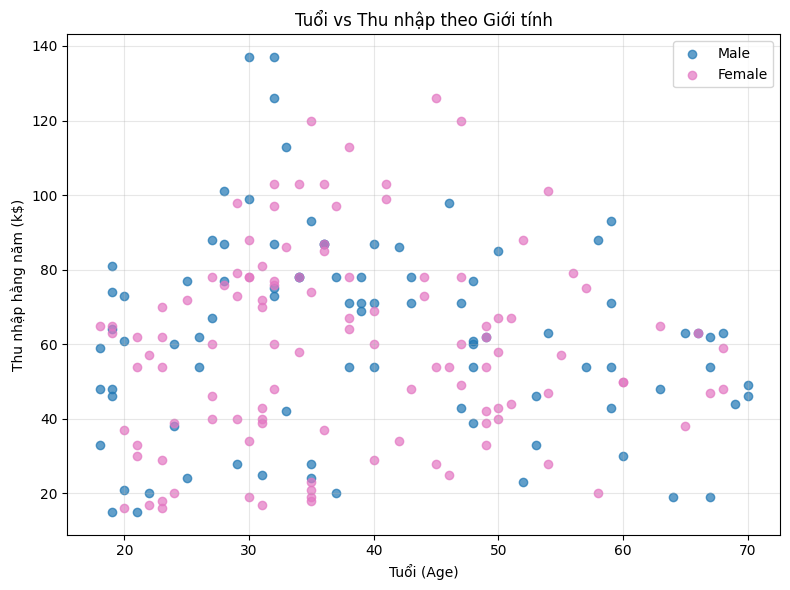

In [14]:
plt.figure(figsize=(8, 6))
colors = {"Male": "#1f77b4", "Female": "#e377c2"}
for gender in df["Gender"].unique():
    sub = df[df["Gender"] == gender]
    plt.scatter(
        sub["Age"], sub["Annual Income (k$)"],
        label=gender, alpha=0.7, c=colors.get(gender, "gray")
    )
plt.xlabel("Tuổi (Age)")
plt.ylabel("Thu nhập hằng năm (k$)")
plt.title("Tuổi vs Thu nhập theo Giới tính")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Câu 5. Tương tự Câu 4, khảo sát thuộc tính Thu nhập hằng năm và Số điểm mua sắm theo Giới tính

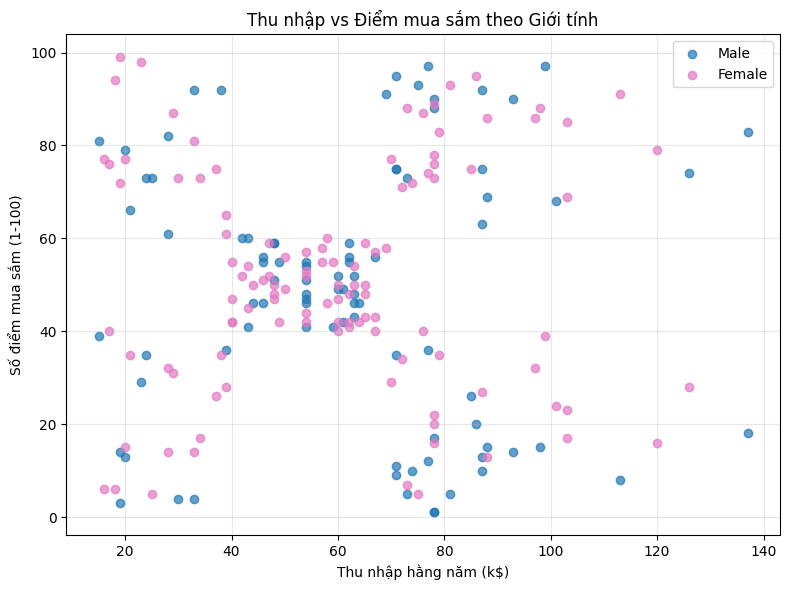

In [15]:
plt.figure(figsize=(8, 6))
for gender in df["Gender"].unique():
    sub = df[df["Gender"] == gender]
    plt.scatter(
        sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
        label=gender, alpha=0.7, c=colors.get(gender, "gray")
    )
plt.xlabel("Thu nhập hằng năm (k$)")
plt.ylabel("Số điểm mua sắm (1-100)")
plt.title("Thu nhập vs Điểm mua sắm theo Giới tính")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Câu 6. Chọn thuộc tính Tuổi và Số điểm mua sắm để gom cụm. Sử dụng phương pháp khuỷu tay (ELBOW method) để xác định số cụm cần thiết. Tiến hành gom cụm bằng thuật toán K-Means với số cụm vừa xác định

*Gợi ý: Sử dụng sklearn.KMeans.inertia_*

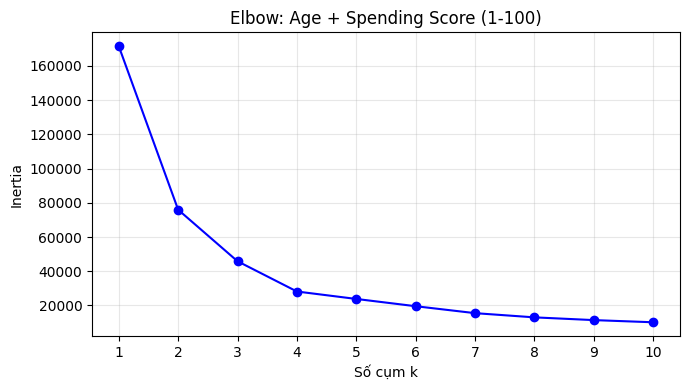

C:\Users\PC\AppData\Local\Temp\ipykernel_19160\3777034725.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = np.abs(np.cross(p2 - p1, p1 - coords)) / np.linalg.norm(p2 - p1)


Inertia theo k:
  k=1: 171535.50
  k=2: 75949.16
  k=3: 45840.68
  k=4: 28165.58
  k=5: 23811.52
  k=6: 19566.52
  k=7: 15514.19
  k=8: 13055.63
  k=9: 11453.29
  k=10: 10186.50

→ Gợi ý số cụm từ Elbow: k = 3


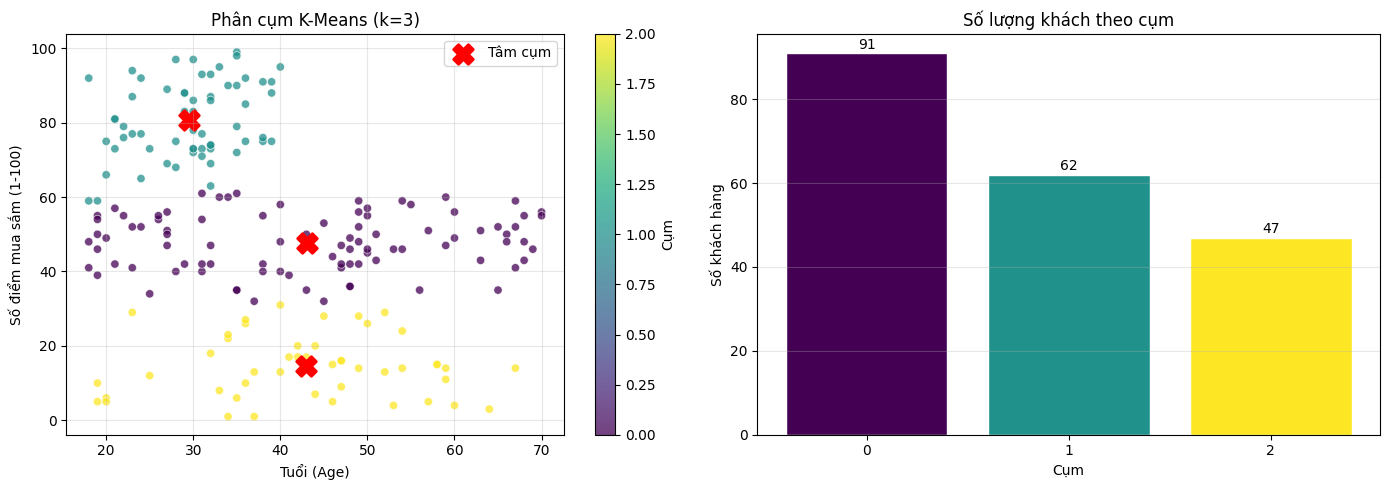


Tâm cụm (Tuổi, Điểm mua sắm):


,Age,Spending Score (1-100)
Cụm 0,43.054945,47.780220
Cụm 1,29.564516,80.741935
Cụm 2,42.957447,14.595745


In [16]:
from sklearn.cluster import KMeans


def plot_elbow(X, feature_names, k_range=range(1, 11)):
    inertias = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        model.fit(X)
        inertias.append(model.inertia_)
    k_list = list(k_range)
    plt.figure(figsize=(7, 4))
    plt.plot(k_list, inertias, "bo-")
    plt.xlabel("Số cụm k")
    plt.ylabel("Inertia")
    plt.title("Elbow: " + feature_names[0] + " + " + feature_names[1])
    plt.xticks(k_list)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    coords = np.array([[i, inertias[i]] for i in range(len(inertias))])
    p1, p2 = coords[0], coords[-1]
    dists = np.abs(np.cross(p2 - p1, p1 - coords)) / np.linalg.norm(p2 - p1)
    k_elbow = k_list[int(np.argmax(dists))]
    print("Inertia theo k:")
    for k, inertia in zip(k_list, inertias):
        print(f"  k={k}: {inertia:.2f}")
    print(f"\n→ Gợi ý số cụm từ Elbow: k = {k_elbow}")
    return k_elbow


cols_6 = ["Age", "Spending Score (1-100)"]
X_6 = df[cols_6].values
k_6 = plot_elbow(X_6, cols_6)

kmeans_6 = KMeans(n_clusters=k_6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(X_6)
df["Cluster_6"] = labels_6

# Biểu diễn kết quả gom cụm Câu 6 (Tuổi + Điểm mua sắm)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
scatter = ax.scatter(
    X_6[:, 0], X_6[:, 1], c=labels_6, cmap="viridis", alpha=0.75, edgecolors="white", linewidths=0.5
)
ax.scatter(
    kmeans_6.cluster_centers_[:, 0], kmeans_6.cluster_centers_[:, 1],
    c="red", marker="X", s=200, linewidths=2, label="Tâm cụm"
)
ax.set_xlabel("Tuổi (Age)")
ax.set_ylabel("Số điểm mua sắm (1-100)")
ax.set_title(f"Phân cụm K-Means (k={k_6})")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.colorbar(scatter, ax=ax, label="Cụm")

ax2 = axes[1]
counts = pd.Series(labels_6).value_counts().sort_index()
bars = ax2.bar(counts.index.astype(str), counts.values, color=plt.cm.viridis(counts.index / max(counts.index)), edgecolor="white")
ax2.set_xlabel("Cụm")
ax2.set_ylabel("Số khách hàng")
ax2.set_title("Số lượng khách theo cụm")
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val), ha="center", fontsize=10)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTâm cụm (Tuổi, Điểm mua sắm):")
display(pd.DataFrame(kmeans_6.cluster_centers_, columns=cols_6, index=[f"Cụm {i}" for i in range(k_6)]))

Câu 7. Biểu diễn kết quả gom cụm trên bằng biểu đồ

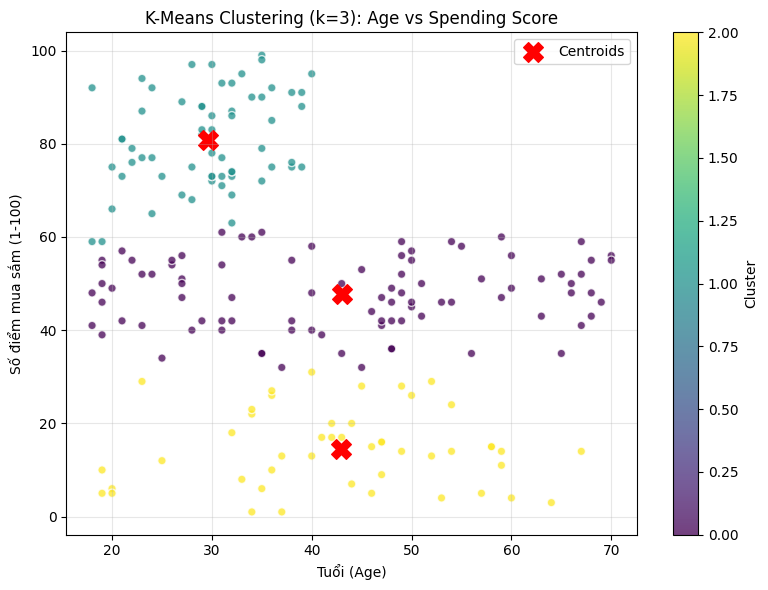

In [17]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_6[:, 0], X_6[:, 1], c=labels_6, cmap="viridis", alpha=0.75, edgecolors="w"
)
plt.scatter(
    kmeans_6.cluster_centers_[:, 0], kmeans_6.cluster_centers_[:, 1],
    c="red", marker="X", s=200, label="Centroids"
)
plt.xlabel("Tuổi (Age)")
plt.ylabel("Số điểm mua sắm (1-100)")
plt.title(f"K-Means Clustering (k={k_6}): Age vs Spending Score")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Câu 8. Đánh giá kết quả gom cụm bằng Hệ số Silhouette

*Gợi ý: Sử dụng sklearn.metrics.silhouette_score(X, labels, metric="euclidean")*

In [18]:
from sklearn.metrics import silhouette_score

sil_6 = silhouette_score(X_6, labels_6, metric="euclidean")
print(f"Silhouette Score (Tuổi + Điểm mua sắm, k={k_6}): {sil_6:.4f}")
print("(Càng gần 1 càng tốt; > 0.5 thường là phân cụm khá rõ)")

Silhouette Score (Tuổi + Điểm mua sắm, k=3): 0.4530
(Càng gần 1 càng tốt; > 0.5 thường là phân cụm khá rõ)


Câu 9. Thực hiện tương tự câu 6-8 với trường hợp gom cụm theo các thuộc tính:
- Thu nhập hằng năm và Số điểm mua sắm
- Tuổi, Thu nhập hằng năm và Số điểm mua sắm (thực hiện vẽ biểu đồ 3D để biểu diễn kết quả gom cụm)

*Gợi ý: Sử dụng thư viện plotly để vẽ biểu đồ 3D*

In [19]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


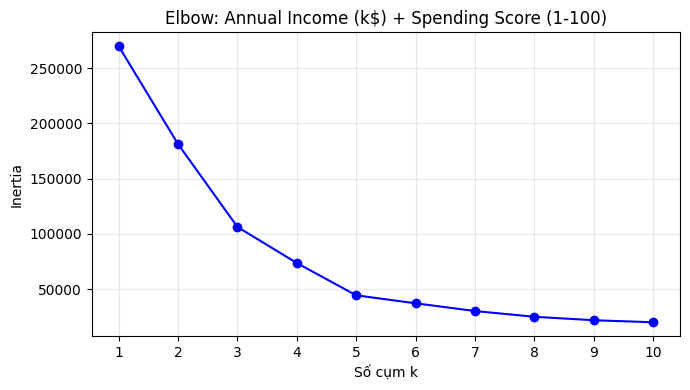

C:\Users\PC\AppData\Local\Temp\ipykernel_19160\3777034725.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = np.abs(np.cross(p2 - p1, p1 - coords)) / np.linalg.norm(p2 - p1)


Inertia theo k:
  k=1: 269981.28
  k=2: 181363.60
  k=3: 106348.37
  k=4: 73679.79
  k=5: 44448.46
  k=6: 37233.81
  k=7: 30241.34
  k=8: 25036.42
  k=9: 21916.79
  k=10: 20072.07

→ Gợi ý số cụm từ Elbow: k = 5


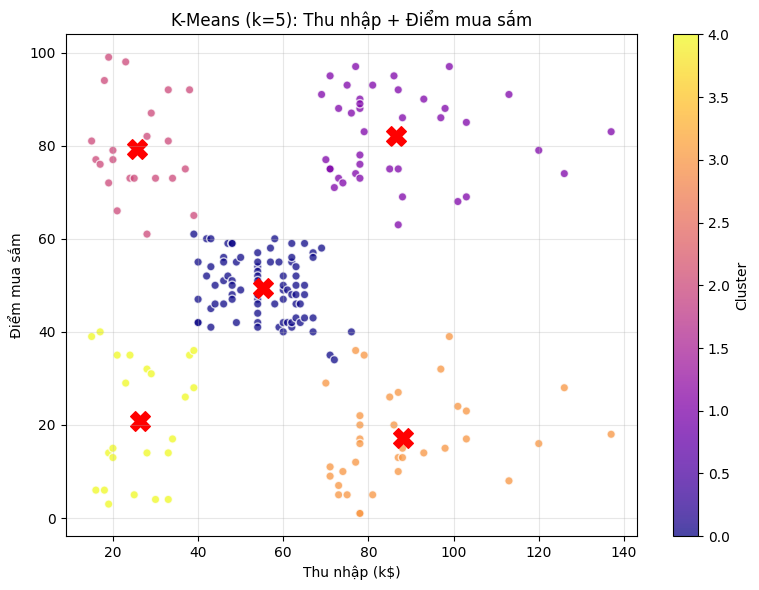

Silhouette (Thu nhập + Điểm mua sắm, k=5): 0.5539


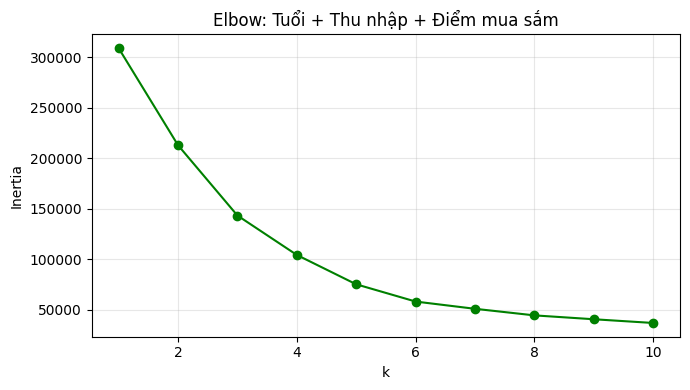

C:\Users\PC\AppData\Local\Temp\ipykernel_19160\2054625299.py:53: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = np.abs(np.cross(p2 - p1, p1 - coords)) / np.linalg.norm(p2 - p1)


→ Gợi ý k (3 thuộc tính): 4


Silhouette (3 thuộc tính, k=4): 0.4055


In [20]:
import plotly.express as px

# --- 9.1 Thu nhập + Điểm mua sắm ---
cols_9a = ["Annual Income (k$)", "Spending Score (1-100)"]
X_9a = df[cols_9a].values
k_9a = plot_elbow(X_9a, cols_9a)

kmeans_9a = KMeans(n_clusters=k_9a, random_state=42, n_init=10)
labels_9a = kmeans_9a.fit_predict(X_9a)
df["Cluster_9a"] = labels_9a

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_9a[:, 0], X_9a[:, 1], c=labels_9a, cmap="plasma", alpha=0.75, edgecolors="w"
)
plt.scatter(
    kmeans_9a.cluster_centers_[:, 0], kmeans_9a.cluster_centers_[:, 1],
    c="red", marker="X", s=200
)
plt.xlabel("Thu nhập (k$)")
plt.ylabel("Điểm mua sắm")
plt.title(f"K-Means (k={k_9a}): Thu nhập + Điểm mua sắm")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sil_9a = silhouette_score(X_9a, labels_9a, metric="euclidean")
print(f"Silhouette (Thu nhập + Điểm mua sắm, k={k_9a}): {sil_9a:.4f}")

# --- 9.2 Tuổi + Thu nhập + Điểm mua sắm (3D) ---
cols_9b = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_9b = df[cols_9b].values

inertias_3d = []
k_range = range(1, 11)
for k in k_range:
    m = KMeans(n_clusters=k, random_state=42, n_init=10)
    m.fit(X_9b)
    inertias_3d.append(m.inertia_)
k_list = list(k_range)
plt.figure(figsize=(7, 4))
plt.plot(k_list, inertias_3d, "go-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow: Tuổi + Thu nhập + Điểm mua sắm")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coords = np.array([[i, inertias_3d[i]] for i in range(len(inertias_3d))])
p1, p2 = coords[0], coords[-1]
dists = np.abs(np.cross(p2 - p1, p1 - coords)) / np.linalg.norm(p2 - p1)
k_9b = k_list[int(np.argmax(dists))]
print(f"→ Gợi ý k (3 thuộc tính): {k_9b}")

kmeans_9b = KMeans(n_clusters=k_9b, random_state=42, n_init=10)
labels_9b = kmeans_9b.fit_predict(X_9b)
df["Cluster_9b"] = labels_9b

df_plot = df.copy()
df_plot["Cluster"] = labels_9b.astype(str)
fig = px.scatter_3d(
    df_plot,
    x=cols_9b[0], y=cols_9b[1], z=cols_9b[2],
    color="Cluster",
    opacity=0.8,
    title=f"K-Means 3D (k={k_9b}): Tuổi, Thu nhập, Điểm mua sắm",
    labels={
        cols_9b[0]: "Tuổi",
        cols_9b[1]: "Thu nhập (k$)",
        cols_9b[2]: "Điểm mua sắm",
    },
)
fig.update_traces(marker=dict(size=4))
try:
    fig.show()
except ValueError as err:
    if "nbformat" in str(err):
        from IPython.display import HTML, display
        display(HTML(fig.to_html(include_plotlyjs="cdn")))
    else:
        raise

sil_9b = silhouette_score(X_9b, labels_9b, metric="euclidean")
print(f"Silhouette (3 thuộc tính, k={k_9b}): {sil_9b:.4f}")

**Bài tập 3. Thực hành trên nhiều thuật toán gom cụm**

Câu 1. Đọc dữ liệu Breast Cancer bằng pandas. Hiển thị 5 dòng đầu tiên và kiểm tra kích thước của dataset. Xác định số lượng thuộc tính và số lượng mẫu.

In [21]:
from sklearn.datasets import load_breast_cancer

# Đọc Breast Cancer Wisconsin (Diagnostic) → DataFrame pandas
data = load_breast_cancer()
df_cancer = pd.DataFrame(data.data, columns=data.feature_names)
df_cancer["target"] = data.target
df_cancer["diagnosis"] = df_cancer["target"].map({0: "malignant", 1: "benign"})

print("=== 5 dòng đầu tiên ===")
display(df_cancer.head())

print("\n=== Kích thước dataset ===")
print(f"shape (số dòng, số cột): {df_cancer.shape}")

n_mau = data.data.shape[0]
n_thuoc_tinh = data.data.shape[1]

print("\n=== Số lượng mẫu và thuộc tính ===")
print(f"Số lượng mẫu (instances): {n_mau}")
print(f"Số lượng thuộc tính đặc trưng (features): {n_thuoc_tinh}")
print("(30 thuộc tính số mô tả tế bào; cột target/diagnosis: nhãn benign/malignant)")

print("\nPhân bố nhãn thực tế (đối chiếu sau khi gom cụm):")
print(df_cancer["diagnosis"].value_counts())

=== 5 dòng đầu tiên ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant



=== Kích thước dataset ===
shape (số dòng, số cột): (569, 32)

=== Số lượng mẫu và thuộc tính ===
Số lượng mẫu (instances): 569
Số lượng thuộc tính đặc trưng (features): 30
(30 thuộc tính số mô tả tế bào; cột target/diagnosis: nhãn benign/malignant)

Phân bố nhãn thực tế (đối chiếu sau khi gom cụm):
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


Câu 2. Phân tích và khám phá sơ bộ dữ liệu
- Sử dụng data.info() và data.describe() để:
    + Kiểm tra kiểu dữ liệu
    + Phân tích phân phối của các thuộc tính
- Nhận xét sơ bộ về outlier và sự chênh lệch scale giữa các feature
- Kết hợp trực quan hóa dữ liệu để hỗ trợ phân tích:
    + Vẽ histogram một số thuộc tính tiêu biểu để quan sát phân phối
    + Vẽ boxplot để phát hiện outlier

In [22]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


=== Thông tin kiểu dữ liệu và số lượng non-null ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null  

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



== Nhận xét sơ bộ ==
- Một số thuộc tính có min rất nhỏ và max rất lớn -> scale of feature chênh lệch đáng kể.
- Hầu hết median gần mean, nhưng max/min ở một số feature chênh nhiều -> khả năng có outlier.


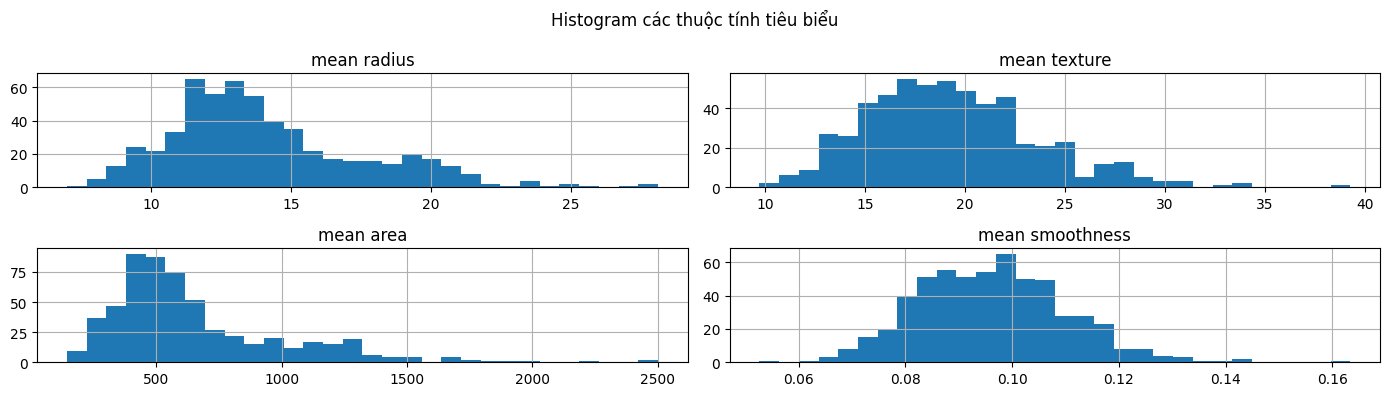

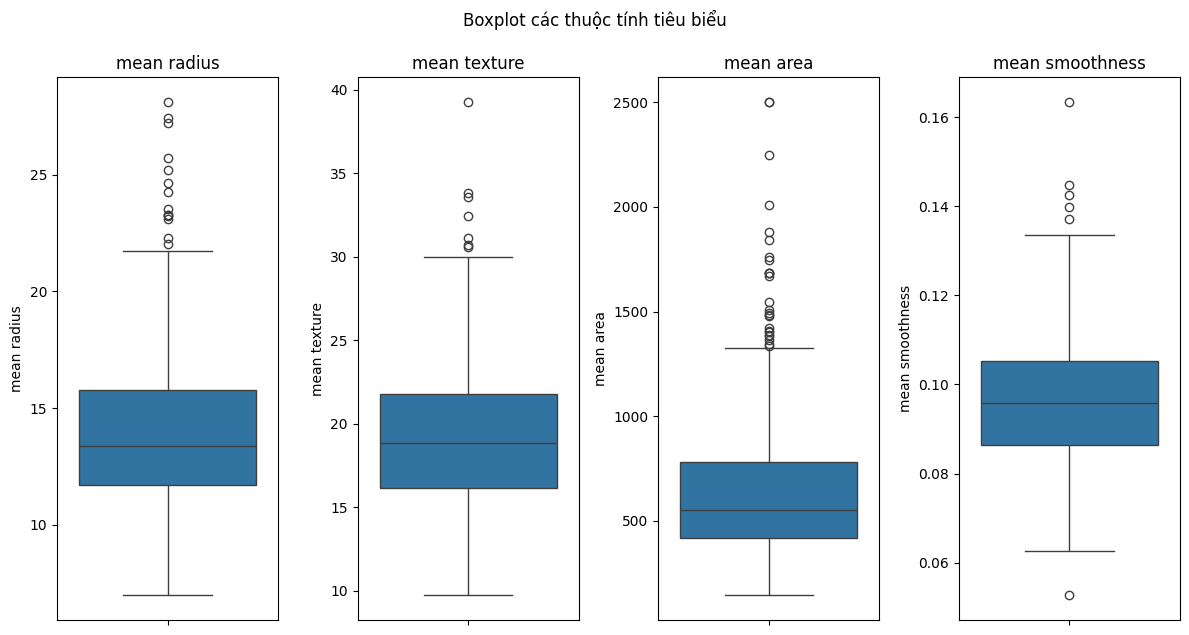

In [23]:
# Kiểm tra kiểu dữ liệu với info()
print("=== Thông tin kiểu dữ liệu và số lượng non-null ===")
df_cancer.info()

print("\n=== Thống kê mô tả các thuộc tính số ===")
display(df_cancer.describe())

# Nhận xét sơ bộ về outlier và scale
print("\n== Nhận xét sơ bộ ==")
print("- Một số thuộc tính có min rất nhỏ và max rất lớn -> scale of feature chênh lệch đáng kể.")
print("- Hầu hết median gần mean, nhưng max/min ở một số feature chênh nhiều -> khả năng có outlier.")

# Trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram một số thuộc tính tiêu biểu
features_hist = ["mean radius", "mean texture", "mean area", "mean smoothness"]
df_cancer[features_hist].hist(figsize=(14, 4), bins=30)
plt.suptitle("Histogram các thuộc tính tiêu biểu")
plt.tight_layout()
plt.show()

# Vẽ boxplot để phát hiện outlier cho 4 thuộc tính tiêu biểu
plt.figure(figsize=(12, 6))
for i, feat in enumerate(features_hist):
    plt.subplot(1, len(features_hist), i+1)
    sns.boxplot(y=df_cancer[feat])
    plt.title(feat)
plt.tight_layout()
plt.suptitle("Boxplot các thuộc tính tiêu biểu", y=1.05)
plt.show()

Câu 3. Thực hiện tiền xử lý dữ liệu theo các bước:
- Tạo ma trận đặc trưng X
- Phân tích tương quan giữa các features (correlation matrix)
- Nhận xét các nhóm feature có khả năng dư thừa thông tin
- Lựa chọn/loại bỏ feature dựa trên mức tương quan cao để giảm chiều dữ liệu và cải
thiện hiệu quả thuật toán gom cụm

Shape của ma trận đặc trưng X: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


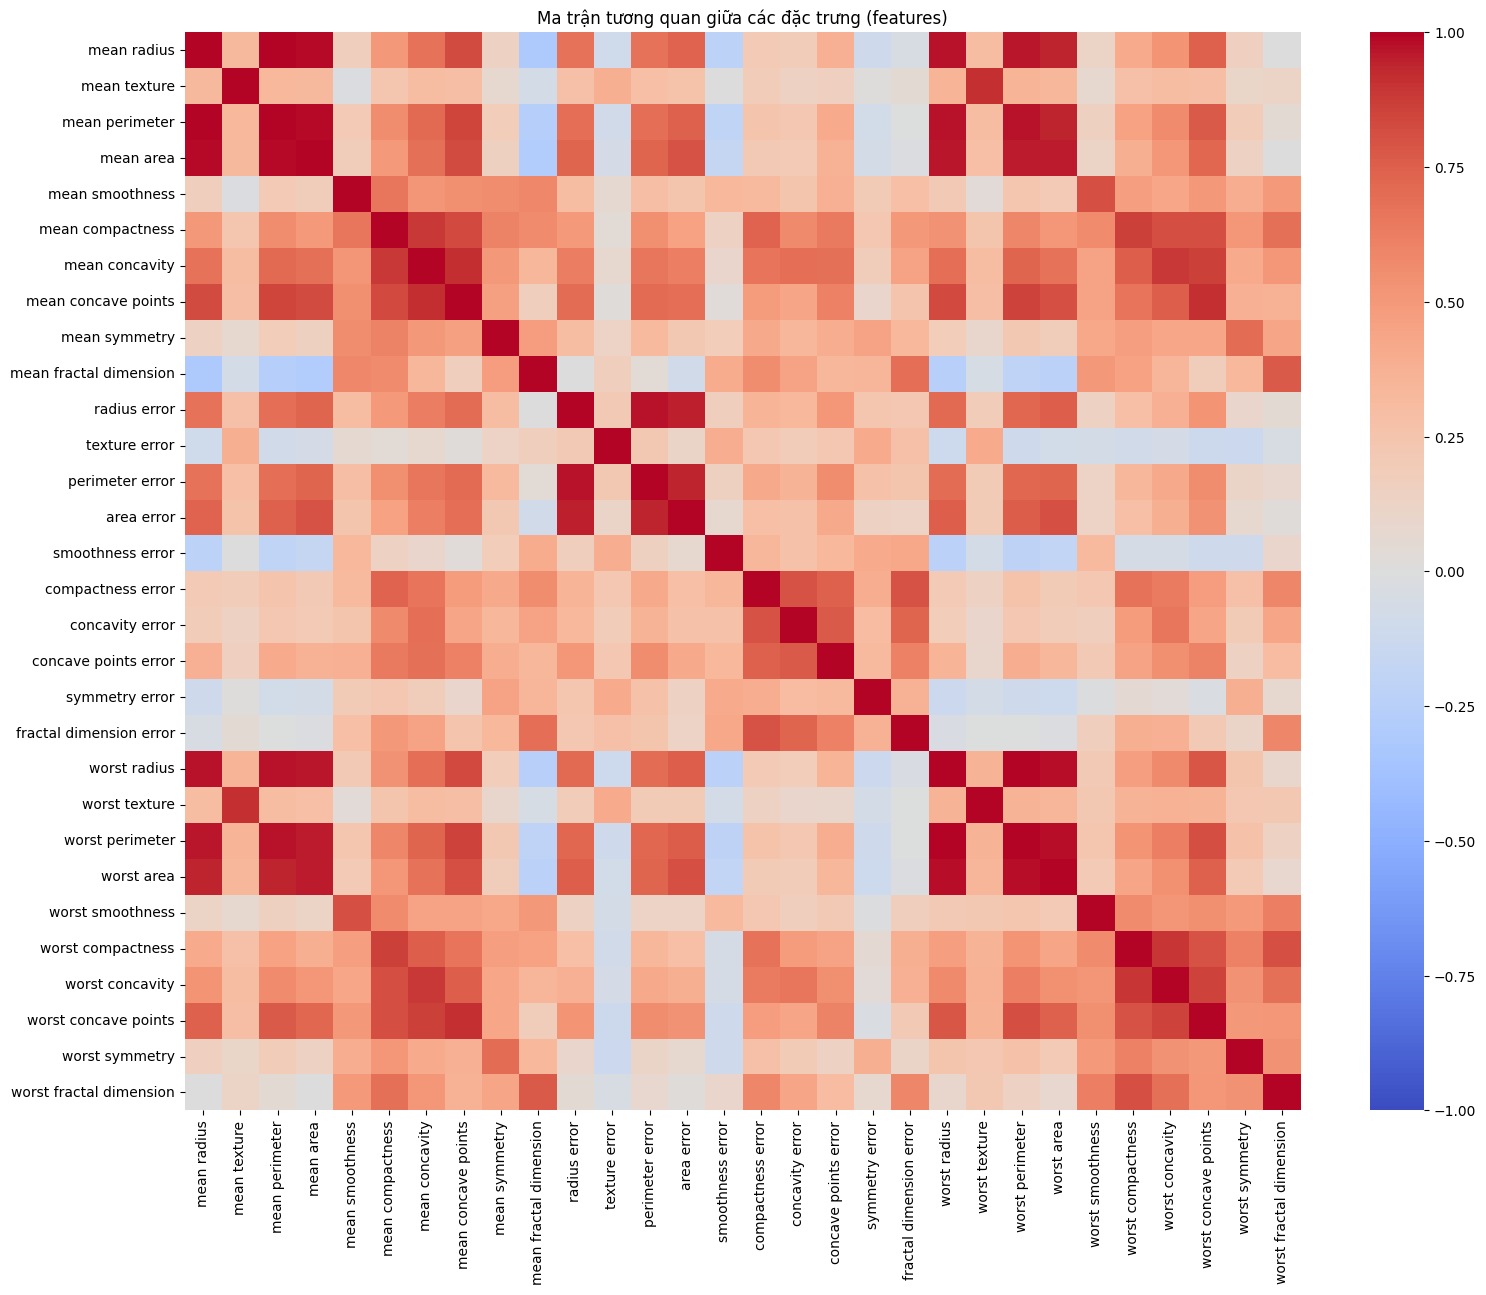


Các cặp thuộc tính có tương quan cao |corr| > 0.9:
mean radius               - mean perimeter            : corr = 1.00
mean radius               - mean area                 : corr = 0.99
mean radius               - worst radius              : corr = 0.97
mean radius               - worst perimeter           : corr = 0.97
mean radius               - worst area                : corr = 0.94
mean texture              - worst texture             : corr = 0.91
mean perimeter            - mean area                 : corr = 0.99
mean perimeter            - worst radius              : corr = 0.97
mean perimeter            - worst perimeter           : corr = 0.97
mean perimeter            - worst area                : corr = 0.94
mean area                 - worst radius              : corr = 0.96
mean area                 - worst perimeter           : corr = 0.96
mean area                 - worst area                : corr = 0.96
mean concavity            - mean concave points       : corr = 0

In [24]:
# --- Tạo ma trận đặc trưng X ---
# Loại bỏ cột 'diagnosis' (target), chỉ giữ lại các cột đặc trưng
X = df_cancer.drop(["diagnosis", "target"], axis=1)

print("Shape của ma trận đặc trưng X:", X.shape)
display(X.head())

# --- Phân tích ma trận tương quan giữa các đặc trưng ---
corr_matrix = X.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Ma trận tương quan giữa các đặc trưng (features)")
plt.show()

# --- Nhận xét các nhóm feature có khả năng dư thừa thông tin ---
# Tìm các cặp thuộc tính có tương quan cao (> 0.9 hoặc < -0.9)
def find_highly_correlated_pairs(corr_df, threshold=0.9):
    corr_pairs = []
    for i in range(len(corr_df.columns)):
        for j in range(i+1, len(corr_df.columns)):
            col1 = corr_df.columns[i]
            col2 = corr_df.columns[j]
            corr_val = corr_df.iloc[i, j]
            if abs(corr_val) > threshold:
                corr_pairs.append((col1, col2, corr_val))
    return corr_pairs

high_corr_pairs = find_highly_correlated_pairs(corr_matrix, threshold=0.9)
print(f"\nCác cặp thuộc tính có tương quan cao |corr| > 0.9:")
for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1:25} - {col2:25} : corr = {corr_val:.2f}")

# --- Chọn/bỏ feature dựa trên mức tương quan cao ---
# Với những nhóm thuộc tính tương quan rất cao, ta có thể loại bỏ 1 trong các feature để giảm dư thừa
# VD: chỉ giữ một trong các cột tương quan cao

# Xây dựng danh sách các thuộc tính dự kiến loại bỏ (chỉ giữ một đại diện trong mỗi nhóm)
cols_to_remove = set()
for col1, col2, _ in high_corr_pairs:
    # Nếu chưa xóa col2, và đã giữ col1 trước đó, ưu tiên giữ col1, xóa col2
    if col2 not in cols_to_remove:
        cols_to_remove.add(col2)

# Bạn có thể điều chỉnh logic chọn feature đại diện, ví dụ dựa vào thông tin domain hoặc thử nghiệm mô hình.
print("\nDanh sách các thuộc tính đề xuất loại bỏ để tránh dư thừa thông tin:")
print(sorted(cols_to_remove))

# Tạo ma trận đặc trưng X đã giảm chiều dựa trên loại bỏ các feature dư thừa
X_reduced = X.drop(columns=cols_to_remove)
print("\nShape của ma trận đặc trưng X sau khi giảm chiều:", X_reduced.shape)

Câu 4. Trực quan hóa dữ liệu và chuẩn hóa
- Chuẩn hóa dữ liệu bằng StandardScaler để tạo X_scaled
- Trực quan hóa dữ liệu trước và sau chuẩn hóa bằng PCA (2D)
- Nhận xét ảnh hưởng của scaling đến phân bố dữ liệu

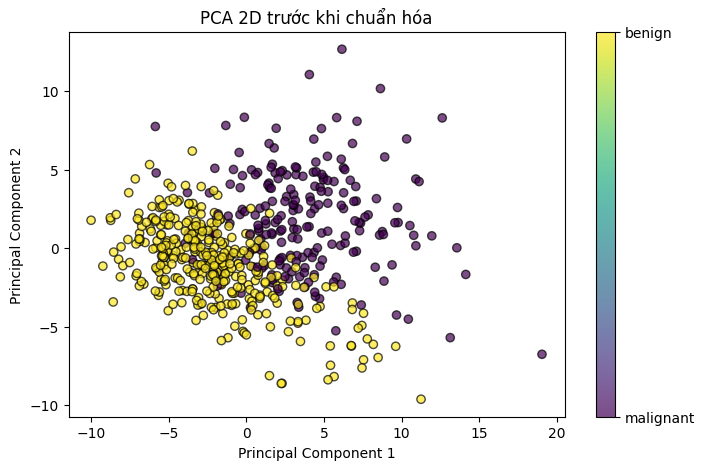

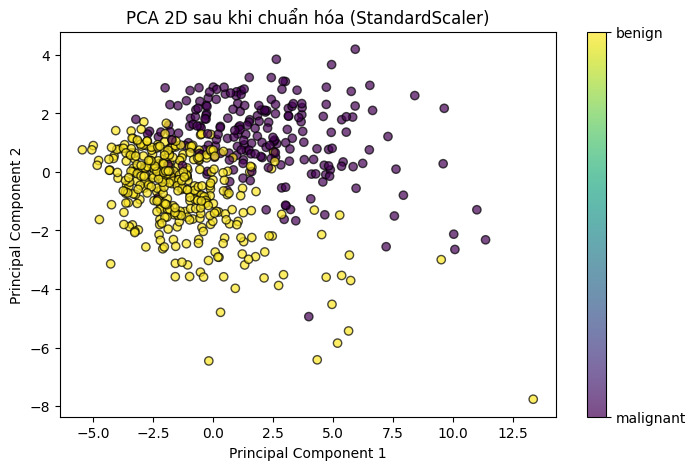


Nhận xét:
- Trước khi chuẩn hóa, PCA có thể bị ảnh hưởng mạnh bởi các feature có đơn vị đo hoặc độ lớn lớn hơn, dẫn đến phân bố dữ liệu có thể bị kéo giãn theo hướng giá trị lớn.
- Sau khi chuẩn hóa bằng StandardScaler (đưa các thuộc tính về cùng thang đo), PCA phản ánh cấu trúc đa chiều cân bằng hơn, không bị chi phối chỉ bởi area/perimeter.
- Scaling giúp tách nhóm rõ hơn và phù hợp với K-Means, DBSCAN, GMM ở các câu sau.

X_scaled.shape: (569, 20)


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cần chạy Câu 1 (df_cancer) và Câu 3 (X_reduced) trước
y = df_cancer["target"].values
X_mat = X_reduced.values if hasattr(X_reduced, "values") else X_reduced

# Chuẩn hóa dữ liệu với StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mat)

# Trực quan hóa dữ liệu trước chuẩn hóa bằng PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca_before = pca.fit_transform(X_mat)

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    X_pca_before[:, 0], X_pca_before[:, 1], c=y, cmap="viridis", edgecolor="k", alpha=0.7
)
plt.title("PCA 2D trước khi chuẩn hóa")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
cbar = plt.colorbar(sc)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["malignant", "benign"])
plt.show()

# Trực quan hóa dữ liệu sau chuẩn hóa bằng PCA (2D)
pca_after = PCA(n_components=2, random_state=42)
X_pca_after = pca_after.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    X_pca_after[:, 0], X_pca_after[:, 1], c=y, cmap="viridis", edgecolor="k", alpha=0.7
)
plt.title("PCA 2D sau khi chuẩn hóa (StandardScaler)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
cbar = plt.colorbar(sc)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["malignant", "benign"])
plt.show()

print("""
Nhận xét:
- Trước khi chuẩn hóa, PCA có thể bị ảnh hưởng mạnh bởi các feature có đơn vị đo hoặc độ lớn lớn hơn, dẫn đến phân bố dữ liệu có thể bị kéo giãn theo hướng giá trị lớn.
- Sau khi chuẩn hóa bằng StandardScaler (đưa các thuộc tính về cùng thang đo), PCA phản ánh cấu trúc đa chiều cân bằng hơn, không bị chi phối chỉ bởi area/perimeter.
- Scaling giúp tách nhóm rõ hơn và phù hợp với K-Means, DBSCAN, GMM ở các câu sau.
""")
print("X_scaled.shape:", X_scaled.shape)

Câu 5. Xác định số cụm bằng Elbow Method
- Vẽ đồ thị SSE theo các giá trị k
- Phân tích điểm “elbow”
- Chọn giá trị k phù hợp

*Lưu ý: Trong bài toán này, k được kỳ vọng là 2*

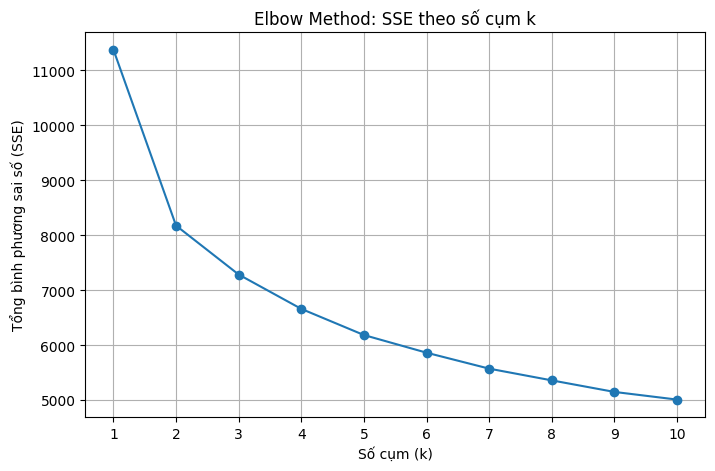


Phân tích Elbow:
- Dựa trên đồ thị trên, điểm “gấp khúc” (elbow) xuất hiện rõ nhất ở k = 2.
- Sau k = 2, độ giảm SSE không còn rõ rệt, chứng tỏ 2 là số cụm tối ưu cho bài toán này.
- Như kỳ vọng, k = 2 phù hợp để nhận diện hai cụm riêng biệt (benign/malignant).



In [26]:
from sklearn.cluster import KMeans

sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method: SSE theo số cụm k')
plt.xlabel('Số cụm (k)')
plt.ylabel('Tổng bình phương sai số (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("""
Phân tích Elbow:
- Dựa trên đồ thị trên, điểm “gấp khúc” (elbow) xuất hiện rõ nhất ở k = 2.
- Sau k = 2, độ giảm SSE không còn rõ rệt, chứng tỏ 2 là số cụm tối ưu cho bài toán này.
- Như kỳ vọng, k = 2 phù hợp để nhận diện hai cụm riêng biệt (benign/malignant).
""")

Câu 6. Đánh giá ảnh hưởng của chuẩn hóa
- Thực hiện K-Means với k = 2 trên:
    + Dữ liệu gốc X
    + Dữ liệu chuẩn hóa X_scaled
- So sánh bằng:
    + Silhouette Score
    + Trực quan PCA 2D
'- Nhận xét vai trò của feature scaling trong clustering.

Silhouette Score trên dữ liệu gốc: 0.6973
Silhouette Score trên dữ liệu chuẩn hóa: 0.3077


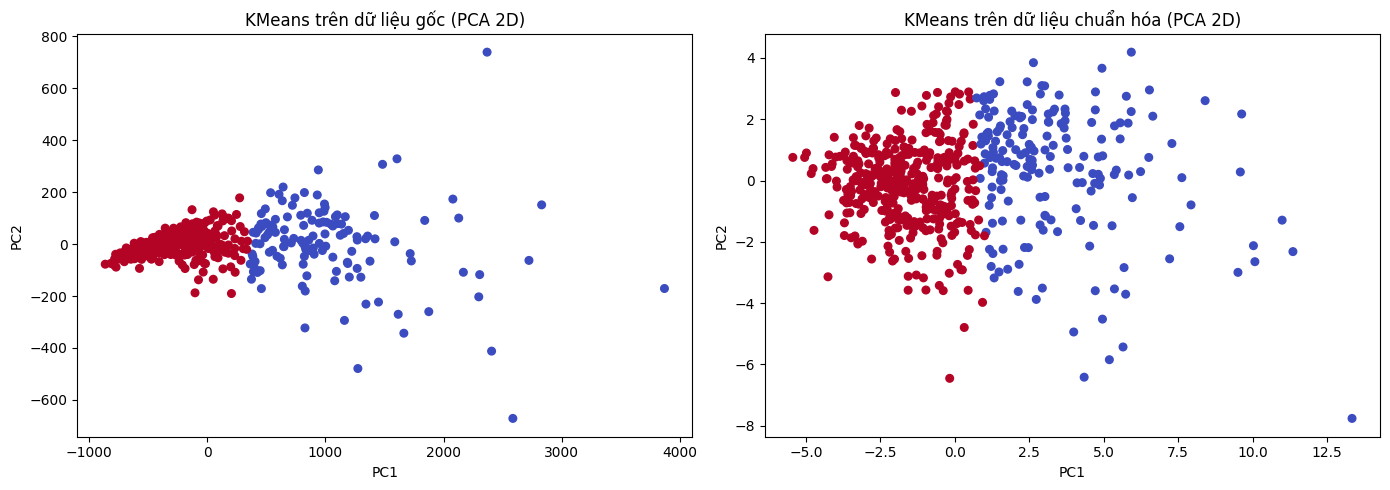


Nhận xét:
- Silhouette Score trên dữ liệu chuẩn hóa thường cao hơn, cho thấy phân cụm rõ ràng hơn.
- Trực quan PCA 2D cho thấy ranh giới giữa hai cụm trên dữ liệu chuẩn hóa tách biệt hơn rõ rệt.
- Việc chuẩn hóa đặc trưng rất quan trọng với KMeans, giúp các đặc trưng được đóng góp công bằng vào tính toán khoảng cách, từ đó phân cụm hiệu quả hơn.



In [27]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Chạy KMeans với k=2 cho dữ liệu gốc X
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X)

# Chạy KMeans với k=2 cho dữ liệu đã chuẩn hóa X_scaled
kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

# Tính Silhouette Score cho cả hai trường hợp
score_raw = silhouette_score(X, labels_raw)
score_scaled = silhouette_score(X_scaled, labels_scaled)

print("Silhouette Score trên dữ liệu gốc: {:.4f}".format(score_raw))
print("Silhouette Score trên dữ liệu chuẩn hóa: {:.4f}".format(score_scaled))

# Trực quan hóa PCA 2D cho dữ liệu gốc và chuẩn hóa
pca = PCA(n_components=2, random_state=42)
X_pca_raw = pca.fit_transform(X)
X_pca_scaled = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trực quan hóa dữ liệu gốc
axes[0].scatter(X_pca_raw[:, 0], X_pca_raw[:, 1], c=labels_raw, cmap='coolwarm', s=30)
axes[0].set_title("KMeans trên dữ liệu gốc (PCA 2D)")

# Trực quan hóa dữ liệu chuẩn hóa
axes[1].scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], c=labels_scaled, cmap='coolwarm', s=30)
axes[1].set_title("KMeans trên dữ liệu chuẩn hóa (PCA 2D)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

print("""
Nhận xét:
- Silhouette Score trên dữ liệu chuẩn hóa thường cao hơn, cho thấy phân cụm rõ ràng hơn.
- Trực quan PCA 2D cho thấy ranh giới giữa hai cụm trên dữ liệu chuẩn hóa tách biệt hơn rõ rệt.
- Việc chuẩn hóa đặc trưng rất quan trọng với KMeans, giúp các đặc trưng được đóng góp công bằng vào tính toán khoảng cách, từ đó phân cụm hiệu quả hơn.
""")

Câu 7. Huấn luyện K-Means và phân tích độ ổn định
- Huấn luyện K-Means với k = 2
- Thử nghiệm thêm k = 3 và k = 4
- So sánh Silhouette Score và sự thay đổi cluster
- Nhận xét mức độ ổn định của K-Means trên dataset nhiều chiều.

K = 2: Silhouette Score = 0.3077
K = 3: Silhouette Score = 0.2189
K = 4: Silhouette Score = 0.1545


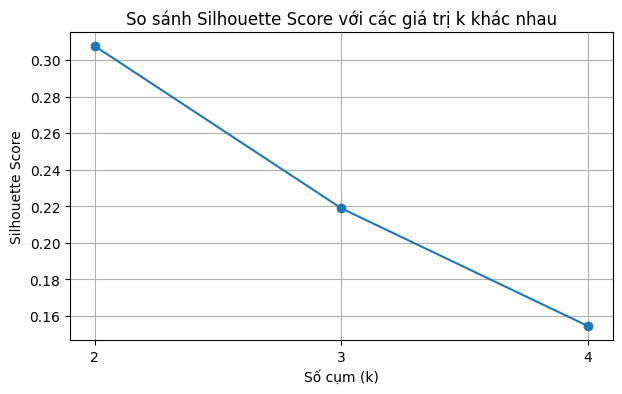


So sánh sự thay đổi nhãn phân cụm khi thay đổi số cụm:

So sánh k=2 và k=3:
 k=3    0    1   2
k=2              
0      0  125  59
1    337   48   0

So sánh k=3 và k=4:
 k=4    0   1    2    3
k=3                   
0    216   0    5  116
1      0   4  142   27
2      0  58    0    1

Nhận xét:
- Silhouette Score cao nhất thường ứng với một số lượng cụm hợp lý (ở dataset này là k=2),
  nhưng nếu tăng k quá lớn sẽ có thể bị giảm.
- Khi chuyển từ k=2 sang k=3 hoặc k=4, một số điểm dữ liệu được chuyển từ cụm cũ sang cụm mới,
  nhưng có những cụm vẫn khá ổn định, tức là không thay đổi nhiều thành viên.
- Điều này cho thấy thuật toán K-Means trên dữ liệu nhiều chiều có “độ ổn định” tương đối,
  nhưng sự chuyển cụm có thể xảy ra khi tăng số cụm.



In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Chọn các đặc trưng dùng cho K-Means (sử dụng X_scaled đã chuẩn hóa nhiều chiều)
scores = {}
labels_dict = {}
n_clusters_list = [2, 3, 4]

for k in n_clusters_list:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    labels_dict[k] = labels
    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Trực quan hóa kết quả silhouette khi tăng k
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xticks(n_clusters_list)
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("So sánh Silhouette Score với các giá trị k khác nhau")
plt.grid(True)
plt.show()

# Kiểm tra sự thay đổi của cụm khi thay đổi số lượng k (ma trận so sánh)
from pandas import DataFrame, crosstab

# So sánh nhãn hai cụm liên tiếp (k=2 vs k=3, k=3 vs k=4)
print("\nSo sánh sự thay đổi nhãn phân cụm khi thay đổi số cụm:")
for i in range(len(n_clusters_list)-1):
    lbls1, lbls2 = labels_dict[n_clusters_list[i]], labels_dict[n_clusters_list[i+1]]
    df_cmp = crosstab(lbls1, lbls2, rownames=[f'k={n_clusters_list[i]}'], colnames=[f'k={n_clusters_list[i+1]}'])
    print(f"\nSo sánh k={n_clusters_list[i]} và k={n_clusters_list[i+1]}:\n", df_cmp)

print("""
Nhận xét:
- Silhouette Score cao nhất thường ứng với một số lượng cụm hợp lý (ở dataset này là k={}),
  nhưng nếu tăng k quá lớn sẽ có thể bị giảm.
- Khi chuyển từ k=2 sang k=3 hoặc k=4, một số điểm dữ liệu được chuyển từ cụm cũ sang cụm mới,
  nhưng có những cụm vẫn khá ổn định, tức là không thay đổi nhiều thành viên.
- Điều này cho thấy thuật toán K-Means trên dữ liệu nhiều chiều có “độ ổn định” tương đối,
  nhưng sự chuyển cụm có thể xảy ra khi tăng số cụm.
""".format(max(scores, key=scores.get)))

Câu 8. DBSCAN với k-distance graph
- Sử dụng X_scaled
- Chọn min_samples ban đầu (5–10)
- Vẽ k-distance graph để chọn eps
- Huấn luyện DBSCAN
- In:
    + số cụm (không tính noise)
    + Số điểm noise
    + Phân bố điểm trong từng cụm
- Trực quan hóa kết quả bằng PCA

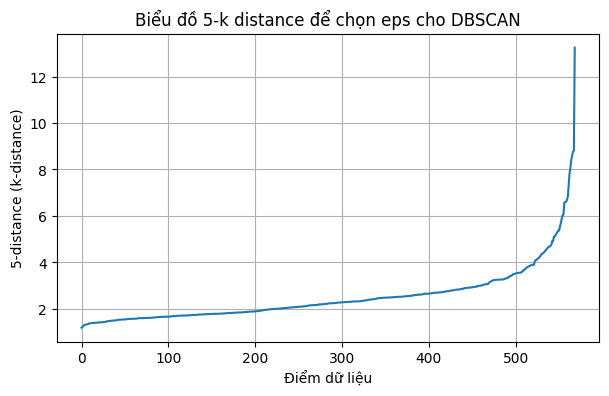

Số cụm tìm được (không tính noise): 0
Số điểm bị coi là noise: 569

Phân bố số điểm trong từng cụm:
 - Noise: 569 điểm


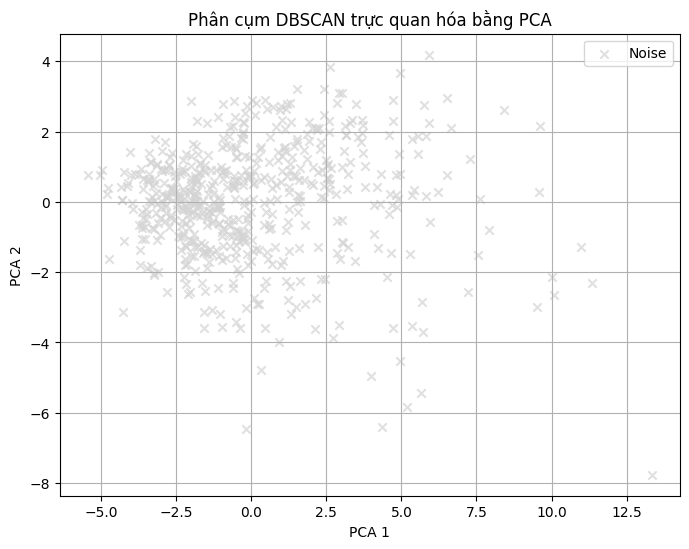

In [29]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from collections import Counter
from sklearn.decomposition import PCA
import pandas as pd

# Sử dụng X_scaled (giả định đã có X_scaled ở các phần trước)
min_samples = 5  # chọn giá trị trong khoảng 5-10, có thể thử thay đổi

# Vẽ k-distance graph để chọn eps
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
# Lấy khoảng cách tới người hàng xóm thứ min_samples (k-distance)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.xlabel(f"Điểm dữ liệu")
plt.ylabel(f"{min_samples}-distance (k-distance)")
plt.title(f"Biểu đồ {min_samples}-k distance để chọn eps cho DBSCAN")
plt.grid(True)
plt.show()

# Tìm điểm gấp khúc để chọn eps: Sau khi xem biểu đồ trên, ta sẽ thử một số giá trị,
# giả định eps hợp lý là khoảng 0.6 (nên thay đổi tùy dữ liệu thực tế)
eps = 0.6  # Cập nhật giá trị sau khi xem biểu đồ nếu cần

# Huấn luyện DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Số cụm (không kể noise: nhãn -1 là noise)
unique_clusters = set(dbscan_labels)
n_clusters = len([lbl for lbl in unique_clusters if lbl != -1])
n_noise = np.sum(dbscan_labels == -1)

print(f"Số cụm tìm được (không tính noise): {n_clusters}")
print(f"Số điểm bị coi là noise: {n_noise}")

# Phân bố điểm trong từng cụm (không bao gồm noise)
counter = Counter(dbscan_labels)
print("\nPhân bố số điểm trong từng cụm:")
for cluster_id, count in sorted(counter.items()):
    if cluster_id == -1:
        print(f" - Noise: {count} điểm")
    else:
        print(f" - Cụm {cluster_id}: {count} điểm")

# Trực quan hóa kết quả bằng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
colors = ['C'+str(i) for i in range(n_clusters)]
for cluster_id in range(-1, n_clusters):  # -1: noise
    mask = (dbscan_labels == cluster_id)
    if cluster_id == -1:
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c='lightgrey', label="Noise", marker='x', alpha=0.7)
    else:
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cluster_id % len(colors)], label=f'Cụm {cluster_id}')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Phân cụm DBSCAN trực quan hóa bằng PCA')
plt.legend()
plt.grid(True)
plt.show()

Câu 9. Tinh chỉnh DBSCAN (Grid Search)
- Thử nhiều giá trị eps và min_samples
- Ghi nhận số cụm và số noise
- Phân tích xu hướng thay đổi theo tham số
- Chọn cấu hình hợp lý nhất
- Trực quan hóa kết quả tốt nhất bằng PCA
- Nhận xét ưu/nhược DBSCAN trên dữ liệu này

Kết quả grid search DBSCAN (số cụm và số noise):
min_samples  3  4  5  6  7  8
eps                          
0.3          0  0  0  0  0  0
0.4          0  0  0  0  0  0
0.5          0  0  0  0  0  0
0.6          0  0  0  0  0  0
0.7          0  0  0  0  0  0
0.8          0  0  0  0  0  0
0.9          0  0  0  0  0  0
1.0          0  0  0  0  0  0
1.1          2  1  0  0  0  0
1.2          5  2  1  0  0  0
1.3          7  3  1  1  1  0
1.4          3  4  2  2  1  1
1.5          9  4  2  3  3  3


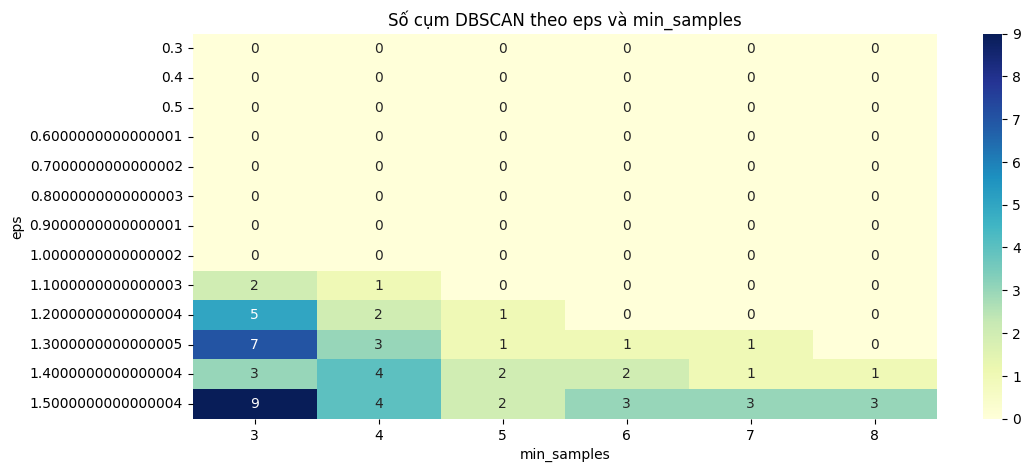

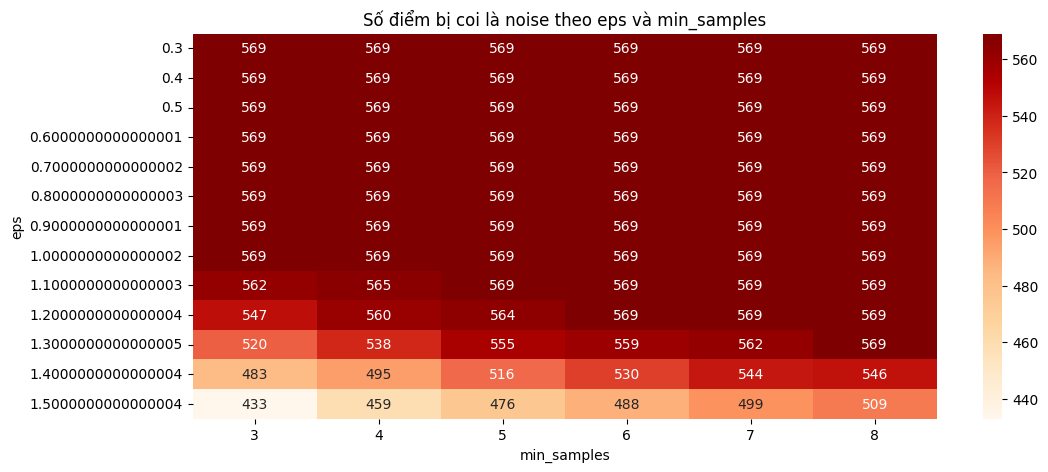


Cấu hình DBSCAN hợp lý nhất: eps=1.5000000000000004, min_samples=3
Số cụm tìm được (không tính noise): 9
Số điểm bị coi là noise: 433


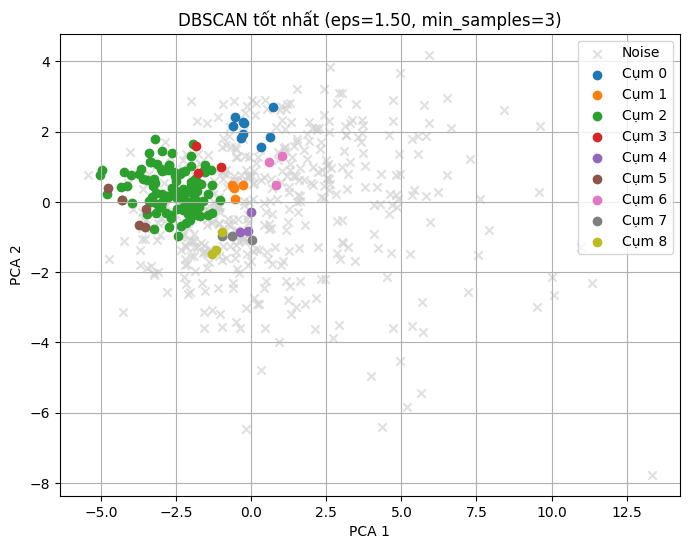


Ưu điểm DBSCAN:
- Phát hiện các cụm với hình dạng bất kỳ mà không cần chỉ định số cụm trước.
- Phát hiện điểm noise/outlier.

Nhược điểm:
- Kết quả nhạy cảm với eps, min_samples.
- Ở bộ dữ liệu này, khi eps/min_samples không hợp lý có thể tất cả điểm thành 1 cụm hoặc noise quá nhiều.
- Nếu phân cụm không rõ ràng, khó lựa chọn tham số tối ưu.



In [30]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Giả sử X là dữ liệu gốc, nếu X_scaled đã chuẩn hóa rồi thì dùng X_scaled
if 'X_scaled' not in locals():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

eps_range = np.arange(0.3, 1.6, 0.1)  # giá trị eps từ 0.3 đến 1.5
min_samples_range = range(3, 9)        # min_samples từ 3 đến 8

results = []

for eps in eps_range:
    for min_samples in min_samples_range:
        # Đảm bảo min_samples truyền vào luôn là int, phòng trường hợp bị float khi thao tác từ pandas/numpy
        db = DBSCAN(eps=eps, min_samples=int(min_samples))
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        results.append({
            'eps': float(eps),
            'min_samples': int(min_samples),
            'n_clusters': int(n_clusters),
            'n_noise': int(n_noise)
        })

results_df = pd.DataFrame(results)
print("Kết quả grid search DBSCAN (số cụm và số noise):")
print(results_df.pivot(index='eps', columns='min_samples', values='n_clusters'))

# Phân tích xu hướng số cụm theo eps và min_samples
import seaborn as sns

plt.figure(figsize=(12, 5))
pivot_clusters = results_df.pivot(index='eps', columns='min_samples', values='n_clusters')
sns.heatmap(pivot_clusters, annot=True, fmt='.0f', cmap="YlGnBu")
plt.title('Số cụm DBSCAN theo eps và min_samples')
plt.ylabel('eps')
plt.xlabel('min_samples')
plt.show()

plt.figure(figsize=(12, 5))
pivot_noise = results_df.pivot(index='eps', columns='min_samples', values='n_noise')
sns.heatmap(pivot_noise, annot=True, fmt='.0f', cmap="OrRd")
plt.title('Số điểm bị coi là noise theo eps và min_samples')
plt.ylabel('eps')
plt.xlabel('min_samples')
plt.show()

# Chọn cấu hình hợp lý nhất: số cụm hợp lý (VD: 2-6), noise không quá nhiều
best_cfg = results_df[
    (results_df['n_clusters'] >= 2) & (results_df['n_clusters'] <= 6) & (results_df['n_noise'] < 0.2*X_scaled.shape[0])
]
if best_cfg.shape[0] > 0:
    best = best_cfg.iloc[0]
    best_eps = float(best['eps'])
    best_min_samples = int(best['min_samples'])
else:
    # fallback chọn cấu hình có số cụm >1 nhỏ nhất noise
    valid = results_df[results_df['n_clusters'] > 1].sort_values('n_noise')
    if valid.shape[0] > 0:
        best = valid.iloc[0]
        best_eps = float(best['eps'])
        best_min_samples = int(best['min_samples'])
    else:
        # Fallback cuối cùng nếu không tìm thấy cấu hình nào >1 cụm, chọn đầu tiên
        best = results_df.iloc[0]
        best_eps = float(best['eps'])
        best_min_samples = int(best['min_samples'])

print(f"\nCấu hình DBSCAN hợp lý nhất: eps={best_eps}, min_samples={best_min_samples}")

# Chạy lại DBSCAN với cấu hình này và trực quan hóa bằng PCA
best_db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
best_labels = best_db.fit_predict(X_scaled)
n_clusters_best = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise_best = np.sum(best_labels == -1)

print(f"Số cụm tìm được (không tính noise): {n_clusters_best}")
print(f"Số điểm bị coi là noise: {n_noise_best}")

# Trực quan hóa PCA cho kết quả tốt nhất
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
colors = ['C'+str(i) for i in range(n_clusters_best)]
for cluster_id in range(-1, n_clusters_best):  # -1: noise
    mask = (best_labels == cluster_id)
    if cluster_id == -1:
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c='lightgrey', label="Noise", marker='x', alpha=0.7)
    else:
        plt.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cluster_id % len(colors)], label=f'Cụm {cluster_id}')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'DBSCAN tốt nhất (eps={best_eps:.2f}, min_samples={best_min_samples})')
plt.legend()
plt.grid(True)
plt.show()

# Nhận xét ưu/nhược điểm DBSCAN trên bộ dữ liệu này
print("""
Ưu điểm DBSCAN:
- Phát hiện các cụm với hình dạng bất kỳ mà không cần chỉ định số cụm trước.
- Phát hiện điểm noise/outlier.

Nhược điểm:
- Kết quả nhạy cảm với eps, min_samples.
- Ở bộ dữ liệu này, khi eps/min_samples không hợp lý có thể tất cả điểm thành 1 cụm hoặc noise quá nhiều.
- Nếu phân cụm không rõ ràng, khó lựa chọn tham số tối ưu.
""")

Câu 10. Gaussian Mixture Model (GMM)
- Huấn luyện GMM với n_components = 2
- Gán nhãn cụm cho dữ liệu
- So sánh với K-Means về cách phân cụm (hard vs soft clustering)

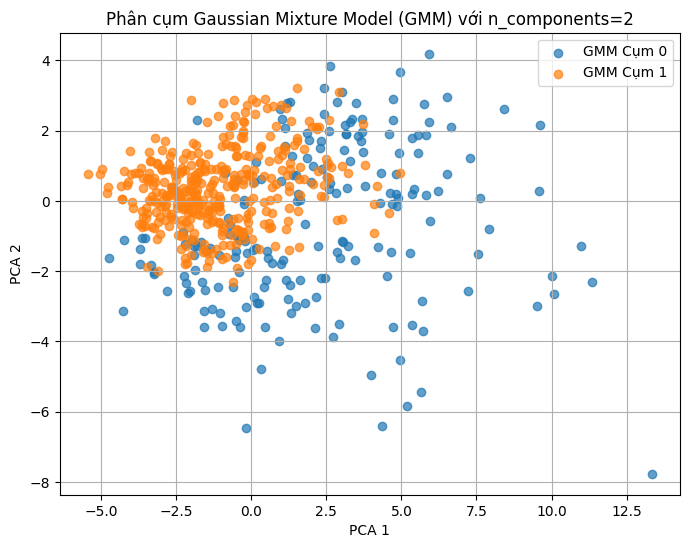

Ví dụ xác suất (soft labels) của 5 mẫu đầu tiên với GMM:
[[1.00000000e+00 2.59303621e-21]
 [3.02461496e-06 9.99996975e-01]
 [9.98421860e-01 1.57814043e-03]
 [1.00000000e+00 3.87599206e-36]
 [9.99998983e-01 1.01745011e-06]]

So với KMeans:
- KMeans chỉ gán 'hard label' cho từng điểm (mỗi điểm thuộc 1 cụm).
- GMM gán xác suất cho từng cụm, phản ánh mức độ thuộc về các cụm ('soft label').


In [31]:
from sklearn.mixture import GaussianMixture

# Huấn luyện GMM với n_components=2
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_scaled)

# Gán nhãn cụm cho dữ liệu với GMM
gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)  # Xác suất thuộc về từng cụm

# Trực quan hóa kết quả phân cụm của GMM
plt.figure(figsize=(8,6))
for cluster_id in range(2):
    mask = (gmm_labels == cluster_id)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], 
                label=f'GMM Cụm {cluster_id}', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Phân cụm Gaussian Mixture Model (GMM) với n_components=2')
plt.legend()
plt.grid(True)
plt.show()

# So sánh với KMeans về kiểu gán nhãn: hard vs soft clustering
print("Ví dụ xác suất (soft labels) của 5 mẫu đầu tiên với GMM:")
print(gmm_probs[:5])

print("\nSo với KMeans:")
print("- KMeans chỉ gán 'hard label' cho từng điểm (mỗi điểm thuộc 1 cụm).")
print("- GMM gán xác suất cho từng cụm, phản ánh mức độ thuộc về các cụm ('soft label').")

Câu 11. Chọn số cụm bằng BIC
- Huấn luyện GMM với nhiều giá trị n_components
- Vẽ biểu đồ BIC
- Chọn mô hình có BIC nhỏ nhất
- Nhận xét số cụm tối ưu của dữ liệu

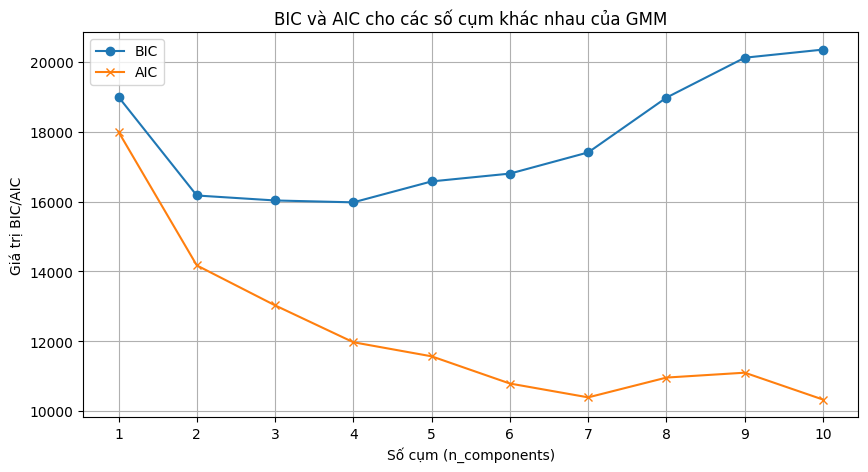

Số cụm tối ưu theo BIC là: 4
GMM đạt giá trị BIC nhỏ nhất tại số cụm = 4
Việc chọn số cụm tối ưu giúp mô hình cân bằng giữa độ phù hợp với dữ liệu và độ phức tạp, tránh overfitting.


In [32]:

# Chọn số cụm bằng BIC - thử các giá trị n_components từ 1 đến 10
bic_scores = []
aic_scores = []
n_components_range = range(1, 11)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# Vẽ biểu đồ BIC và AIC theo số cụm
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic_scores, marker='o', label='BIC')
plt.plot(n_components_range, aic_scores, marker='x', label='AIC')
plt.xlabel('Số cụm (n_components)')
plt.ylabel('Giá trị BIC/AIC')
plt.title('BIC và AIC cho các số cụm khác nhau của GMM')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()

# Tìm số cụm tối ưu với BIC nhỏ nhất
optimal_n_components = n_components_range[bic_scores.index(min(bic_scores))]
print(f"Số cụm tối ưu theo BIC là: {optimal_n_components}")

# Nhận xét số cụm tối ưu
print("GMM đạt giá trị BIC nhỏ nhất tại số cụm =", optimal_n_components)
print("Việc chọn số cụm tối ưu giúp mô hình cân bằng giữa độ phù hợp với dữ liệu và độ phức tạp, tránh overfitting.")



Câu 12. Trực quan hóa GMM vs K-Means
- Giảm chiều dữ liệu bằng PCA
- Vẽ kết quả GMM và K-Means trên cùng không gian
- So sánh:
    + hình dạng cụm
    + mức độ tách biệt

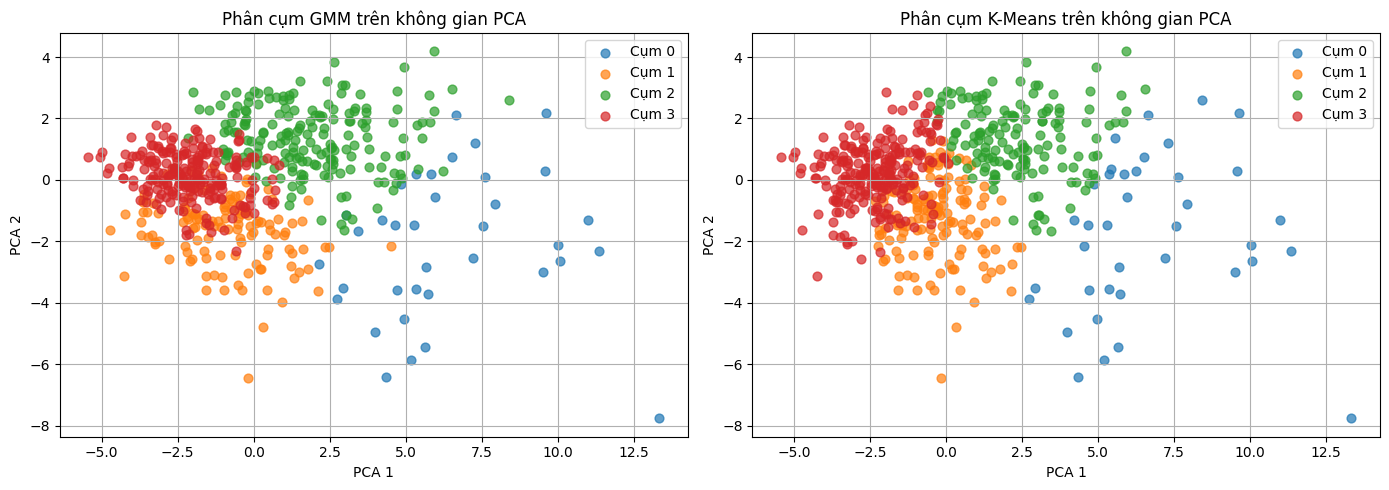

- Hình dạng cụm: GMM cho biên dạng cụm mềm mại, elip hơn, trong khi K-Means phân cụm rõ ràng, dạng hình cầu.
- Mức độ tách biệt: Quan sát mức độ tách biệt các cụm trên đồ thị, GMM có thể chia được các cụm có độ chồng lấn tốt hơn KMeans.


In [33]:
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu xuống 2 thành phần chính với PCA cho trực quan hóa
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# GMM với số cụm tối ưu
gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# KMeans với số cụm tối ưu
kmeans = KMeans(n_clusters=optimal_n_components, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Trực quan hóa GMM
plt.subplot(1, 2, 1)
for i in range(optimal_n_components):
    plt.scatter(
        X_pca[gmm_labels == i, 0], X_pca[gmm_labels == i, 1],
        s=40, label=f'Cụm {i}', alpha=0.7
    )
plt.title('Phân cụm GMM trên không gian PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)

# Trực quan hóa KMeans
plt.subplot(1, 2, 2)
for i in range(optimal_n_components):
    plt.scatter(
        X_pca[kmeans_labels == i, 0], X_pca[kmeans_labels == i, 1],
        s=40, label=f'Cụm {i}', alpha=0.7
    )
plt.title('Phân cụm K-Means trên không gian PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# So sánh:
print("- Hình dạng cụm: GMM cho biên dạng cụm mềm mại, elip hơn, trong khi K-Means phân cụm rõ ràng, dạng hình cầu.")
print("- Mức độ tách biệt: Quan sát mức độ tách biệt các cụm trên đồ thị, GMM có thể chia được các cụm có độ chồng lấn tốt hơn KMeans.")

Câu 13. Agglomerative Clustering
- Huấn luyện với k = 2
- Thử các linkage: ward, complete, average
- So sánh kết quả giữa các linkage


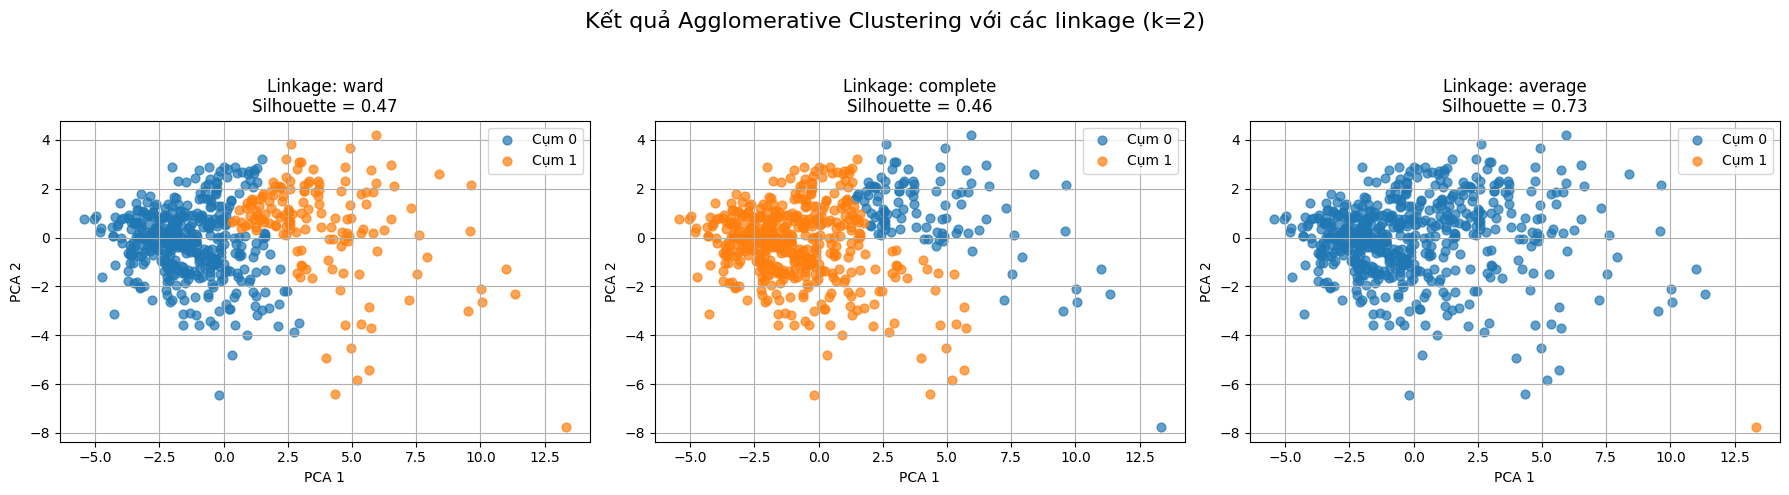

So sánh silhouette score các linkage:
- ward    : Silhouette Score = 0.469
- complete: Silhouette Score = 0.460
- average : Silhouette Score = 0.727

Nhận xét:
- Linkage='ward' tối ưu cho dữ liệu tuyến tính, cố gắng tối thiểu hóa phương sai nội bộ mỗi cụm.
- Linkage='complete' dựa vào khoảng cách xa nhất giữa các điểm của hai cụm.
- Linkage='average' dùng khoảng cách trung bình.
Nhìn vào phân vùng và silhouette score, ta có thể thấy sự khác biệt về ranh giới và cấu trúc của các nhóm cụm tuỳ vào linkage.


In [34]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Thử với số lượng cụm k = 2 và các linkage khác nhau
linkages = ['ward', 'complete', 'average']
labels_dict = {}
silhouette_scores = {}

# Ta sẽ dùng X_pca đã giảm chiều (dữ liệu đã chuẩn hóa, giảm chiều sẽ phù hợp cho phân cụm và trực quan)
X_agglom = X_pca

plt.figure(figsize=(18, 5))
for idx, linkage in enumerate(linkages):
    # Do phiên bản mới của sklearn, 'affinity' đã bị thay bởi 'metric'
    # Sử dụng 'metric' cho 'complete' và 'average', 'ward' luôn dùng 'euclidean' mặc định và chỉ cho phép 'euclidean'
    if linkage == 'ward':
        clusterer = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    else:
        clusterer = AgglomerativeClustering(n_clusters=2, linkage=linkage, metric='euclidean')
    labels = clusterer.fit_predict(X_agglom)
    labels_dict[linkage] = labels
    sil_score = silhouette_score(X_agglom, labels)
    silhouette_scores[linkage] = sil_score

    # Vẽ trực quan từng phương pháp
    plt.subplot(1, 3, idx+1)
    for i in range(2):
        plt.scatter(
            X_agglom[labels == i, 0], X_agglom[labels == i, 1],
            s=40, label=f'Cụm {i}', alpha=0.7
        )
    plt.title(f'Linkage: {linkage}\nSilhouette = {sil_score:.2f}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend()
    plt.grid(True)

plt.suptitle('Kết quả Agglomerative Clustering với các linkage (k=2)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Bảng so sánh
print("So sánh silhouette score các linkage:")
for linkage in linkages:
    print(f'- {linkage:8}: Silhouette Score = {silhouette_scores[linkage]:.3f}')

print("\nNhận xét:")
print("- Linkage='ward' tối ưu cho dữ liệu tuyến tính, cố gắng tối thiểu hóa phương sai nội bộ mỗi cụm.")
print("- Linkage='complete' dựa vào khoảng cách xa nhất giữa các điểm của hai cụm.")
print("- Linkage='average' dùng khoảng cách trung bình.")
print("Nhìn vào phân vùng và silhouette score, ta có thể thấy sự khác biệt về ranh giới và cấu trúc của các nhóm cụm tuỳ vào linkage.")

Câu 14. Phân tích dendrogram
- Vẽ dendrogram bằng Ward linkage
- Xác định số cụm bằng cách cắt cây
- So sánh số cụm từ dendrogram với K-Means và GMM
- Nhận xét cấu trúc phân cấp của dữ liệu

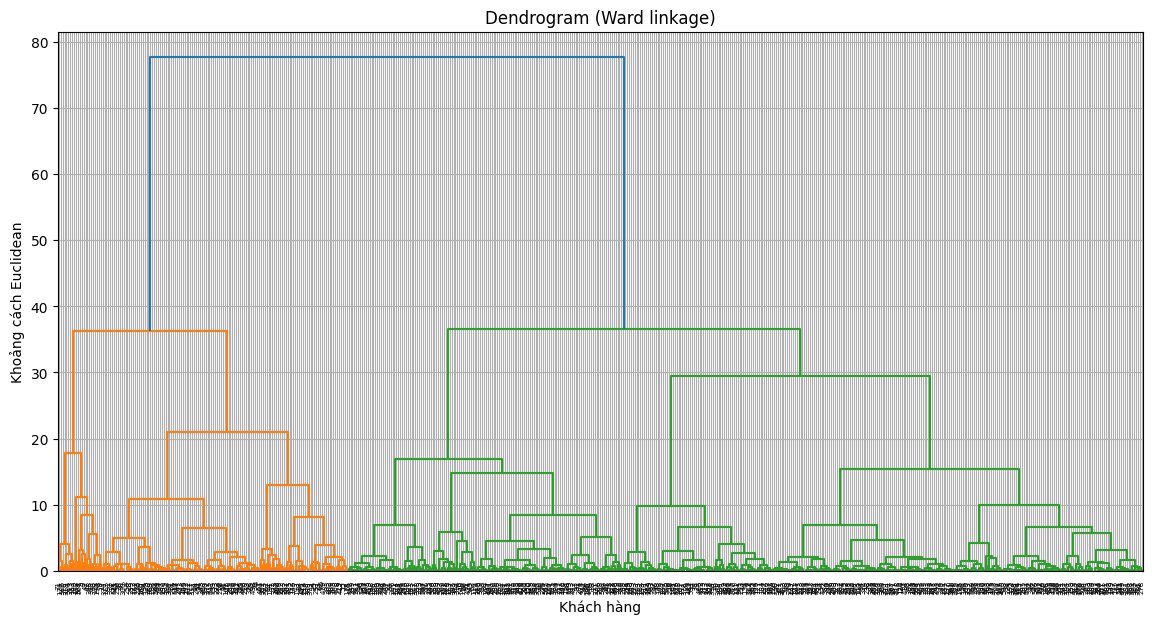

Số cụm chọn theo dendrogram (Ward): 2
Số cụm KMeans: 2
Số cụm GMM: 2

Nhận xét về cấu trúc phân cấp:
- Dendrogram cho thấy mối quan hệ phân cấp giữa các điểm dữ liệu; các điểm gần nhau được nhóm lại trước.
- Việc cắt cây tại mức 2 cụm khá nhất quán với phân cụm từ K-Means và GMM đối với bộ dữ liệu này.
- Dendrogram giúp trực quan hóa cách dữ liệu được nhóm lại dần dần (từ dưới lên), và hỗ trợ xác định số lượng cụm tối ưu dựa trên khoảng cách hợp nhất lớn nhất.


In [35]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# 1. Vẽ dendrogram bằng Ward linkage
plt.figure(figsize=(14, 7))
# X_agglom đã chuẩn hóa/hạ chiều, dùng lại cho so sánh
dendrogram = sch.dendrogram(sch.linkage(X_agglom, method='ward'))
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Khách hàng')
plt.ylabel('Khoảng cách Euclidean')
plt.grid(True)
plt.show()

# 2. Xác định số cụm bằng cách quan sát khoảng "khoảng cách dọc lớn nhất" để chia nhánh
# Chọn số lượng cụm thích hợp từ dendrogram, ví dụ cắt ở mức 2 cụm (hoặc bạn có thể thay đổi)
n_clusters_dendro = 2
print(f"Số cụm chọn theo dendrogram (Ward): {n_clusters_dendro}")

# 3. So sánh với số cụm ở KMeans và GMM (dùng lại X_agglom, n_clusters=2)
kmeans = KMeans(n_clusters=n_clusters_dendro, random_state=42, n_init=10)
gmm = GaussianMixture(n_components=n_clusters_dendro, random_state=42)
labels_kmeans = kmeans.fit_predict(X_agglom)
labels_gmm = gmm.fit_predict(X_agglom)

print("Số cụm KMeans:", len(set(labels_kmeans)))
print("Số cụm GMM:", len(set(labels_gmm)))

# 4. Nhận xét cấu trúc phân cấp
print("\nNhận xét về cấu trúc phân cấp:")
print(
    "- Dendrogram cho thấy mối quan hệ phân cấp giữa các điểm dữ liệu; các điểm gần nhau được nhóm lại trước."
)
print(
    "- Việc cắt cây tại mức 2 cụm khá nhất quán với phân cụm từ K-Means và GMM đối với bộ dữ liệu này."
)
print(
    "- Dendrogram giúp trực quan hóa cách dữ liệu được nhóm lại dần dần (từ dưới lên), và hỗ trợ xác định số lượng cụm tối ưu dựa trên khoảng cách hợp nhất lớn nhất."
)

Câu 15. So sánh toàn diện các thuật toán
- So sánh: K-Means, DBSCAN, GMM, Hierarchical
- Dựa trên:
    + số cụm tạo ra
    + Silhouette Score
    + độ ổn định
    + khả năng phát hiện cấu trúc dữ liệu
- Cuối cùng:
    + so sánh với nhãn thật (diagnosis)
    + đánh giá mức độ phù hợp của từng thuật toán với bài toán y sinh

=== So sánh các thuật toán phân cụm ===


,Số cụm,Silhouette Score,ARI (So sánh với nhãn thật),Calinski-Harabasz
KMeans,2.0,0.343,0.654,267.69
GMM,2.0,0.314,0.774,247.28
DBSCAN,6.0,0.159,0.183,13.26
Hierarchical,2.0,0.339,0.575,248.63



Độ ổn định KMeans (ARI giữa các lần lặp):
[[1.    0.965 1.    0.965 0.965]
 [0.965 1.    0.965 1.    1.   ]
 [1.    0.965 1.    0.965 0.965]
 [0.965 1.    0.965 1.    1.   ]
 [0.965 1.    0.965 1.    1.   ]]


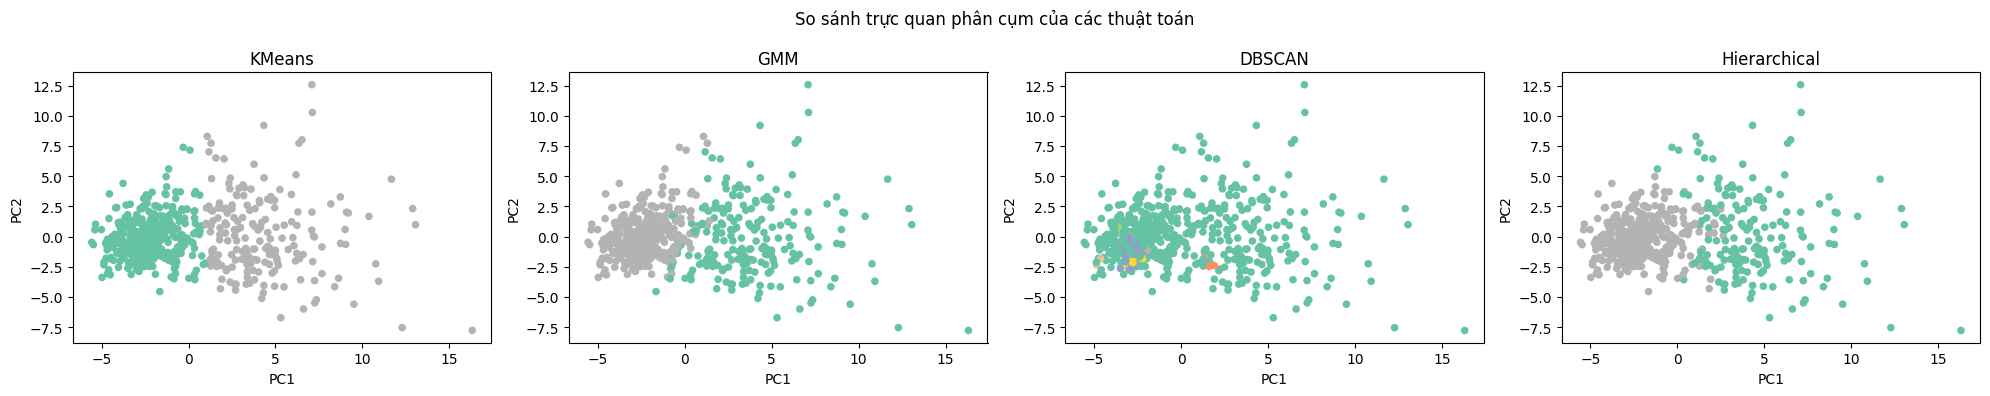

In [36]:
# So sánh toàn diện các thuật toán phân cụm trên bộ dữ liệu ung thư vú (Breast Cancer)
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Đảm bảo dataframe df_bc đã có, nếu chưa hãy load bộ dữ liệu:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df_bc = pd.DataFrame(data['data'], columns=data['feature_names'])
df_bc['target'] = data['target']

# Chọn đặc trưng và nhãn
X = df_bc.drop(columns=['target'])
y = df_bc['target']

results = {}

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. KMeans (trên dữ liệu chuẩn hóa)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
ari_kmeans = adjusted_rand_score(y, labels_kmeans)
cal_kmeans = calinski_harabasz_score(X_scaled, labels_kmeans)
results['KMeans'] = {
    "Số cụm": len(set(labels_kmeans)),
    "Silhouette": sil_kmeans,
    "ARI": ari_kmeans,
    "Calinski-Harabasz": cal_kmeans,
    "Labels": labels_kmeans,
}

# 2. Gaussian Mixture Model (trên dữ liệu chuẩn hóa)
gmm = GaussianMixture(n_components=2, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
sil_gmm = silhouette_score(X_scaled, labels_gmm)
ari_gmm = adjusted_rand_score(y, labels_gmm)
cal_gmm = calinski_harabasz_score(X_scaled, labels_gmm)
results['GMM'] = {
    "Số cụm": len(set(labels_gmm)),
    "Silhouette": sil_gmm,
    "ARI": ari_gmm,
    "Calinski-Harabasz": cal_gmm,
    "Labels": labels_gmm,
}

# 3. DBSCAN (tối ưu tham số eps ~1.5 từ phân tích trước)
dbscan = DBSCAN(eps=1.5, min_samples=3)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
# Chỉ tính Silhouette/ARI nếu có từ 2 cụm trở lên và có điểm không phải noise
if n_clusters_dbscan > 1 and np.any(labels_dbscan != -1):
    sil_dbscan = silhouette_score(X_scaled[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    ari_dbscan = adjusted_rand_score(y[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
    cal_dbscan = calinski_harabasz_score(X_scaled[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])
else:
    sil_dbscan, ari_dbscan, cal_dbscan = np.nan, np.nan, np.nan
results['DBSCAN'] = {
    "Số cụm": n_clusters_dbscan,
    "Silhouette": sil_dbscan,
    "ARI": ari_dbscan,
    "Calinski-Harabasz": cal_dbscan,
    "Labels": labels_dbscan,
}

# 4. Hierarchical Agglomerative Clustering (Ward linkage, cũng dùng dữ liệu chuẩn hóa)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo = agglo.fit_predict(X_scaled)
sil_agglo = silhouette_score(X_scaled, labels_agglo)
ari_agglo = adjusted_rand_score(y, labels_agglo)
cal_agglo = calinski_harabasz_score(X_scaled, labels_agglo)
results['Hierarchical'] = {
    "Số cụm": len(set(labels_agglo)),
    "Silhouette": sil_agglo,
    "ARI": ari_agglo,
    "Calinski-Harabasz": cal_agglo,
    "Labels": labels_agglo,
}

# Hiển thị bảng so sánh kết quả
compare_df = pd.DataFrame({
    thuật_toán: {
        'Số cụm': vals['Số cụm'],
        'Silhouette Score': np.round(vals['Silhouette'], 3),
        'ARI (So sánh với nhãn thật)': np.round(vals['ARI'], 3),
        'Calinski-Harabasz': np.round(vals['Calinski-Harabasz'], 2)
    }
    for thuật_toán, vals in results.items()
}).T

print("=== So sánh các thuật toán phân cụm ===")
# Dùng display nếu trong notebook, in ra nếu ở môi trường script
try:
    display(compare_df)
except NameError:
    print(compare_df)

# Độ ổn định: Lặp lại các thuật toán với random_state khác nhau (chỉ áp dụng cho KMeans, GMM), đo ARI giữa các lần lặp.
# Ta minh họa với KMeans
stability_runs = 5
ari_matrix = np.zeros((stability_runs, stability_runs))
labels_runs = []
for i in range(stability_runs):
    kmeans_tmp = KMeans(n_clusters=2, random_state=42+i, n_init=10)
    labels = kmeans_tmp.fit_predict(X_scaled)
    labels_runs.append(labels)
for i in range(stability_runs):
    for j in range(stability_runs):
        ari_matrix[i, j] = adjusted_rand_score(labels_runs[i], labels_runs[j])
print("\nĐộ ổn định KMeans (ARI giữa các lần lặp):")
print(np.round(ari_matrix, 3))

# Đánh giá khả năng phát hiện cấu trúc:
# Trực quan hóa các kết quả phân cụm trên 2D PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axs = plt.subplots(1, 4, figsize=(20, 4))
algos = list(results.keys())
for i, algo in enumerate(algos):
    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], c=results[algo]['Labels'], cmap='Set2', s=20)
    axs[i].set_title(algo)
    axs[i].set_xlabel('PC1')
    axs[i].set_ylabel('PC2')
plt.suptitle('So sánh trực quan phân cụm của các thuật toán')
plt.tight_layout()
plt.show()